# Detecting XLEAP from Undulator K-Taper

**A data-driven detector that identifies XLEAP, quantifies the undulator taper in MeV/fs, and reports the lasing undulators, from archived $K$ and beam-energy snapshots.**

*N. Mamais, LCLS. 2026-07-01*

---

**Abstract.** X-ray Laser-Enhanced Attosecond Pulse generation (XLEAP) imprints a characteristic *taper* on the undulator line: a monotonic ramp in the deflection parameter $K$ across a run of undulators. This notebook reconstructs, for every archived snapshot, (i) whether such a tapered lasing group exists, (ii) which undulators participate, and (iii) the taper expressed as resonant-energy gain per slippage length in MeV/fs. All physics lives in the [`taper`](taper/) package; the notebook is a thin, reproducible driver over the long-form `snapshots.csv`. We validate the pipeline on the SXR soft line (June 2026), characterise a class of high-taper false positives, and show that they arise from off-nominal beam energy rather than undulator motion.

**Reference:** K.-J. Kim, Z. Huang, and R. Lindberg, *Undulator Radiation*, in *Synchrotron Radiation and Free-Electron Lasers*, Cambridge University Press, 2017, pp. 43 to 45.

## 1. Introduction

In an undulator-based free-electron laser the beam radiates at a resonant wavelength set by the beam energy $\gamma$ and the undulator deflection parameter $K$. **XLEAP** drives the machine into a regime where a short current spike lases while a deliberate *taper*, a controlled increase of $K$ from one undulator to the next, keeps the radiation resonant with the energy-chirped slices of the spike. Operationally, XLEAP therefore shows up as a **"hockey stick"** in the $K$ profile: a flat head followed by a monotonic ramp over several consecutive undulators.

Our task is to turn the machine's archived history into a physically meaningful timeline. For each nominal snapshot time we answer three questions:

1. **Is XLEAP happening?** Does a lasing group of $\ge 4$ tapered undulators exist?
2. **Which undulators lase?** Reported as a `{undulator: K}` map.
3. **What is the taper?** The first (most-upstream) group's taper in **MeV/fs**, from the median $\Delta K$, the group's first $K$, and the beam $\gamma$.

The remainder of the notebook derives the taper from first principles (Section 2), describes the data pipeline and detection algorithm (Section 3), presents the reconstructed timeline (Section 4), validates the result and the motion filter (Section 5), and collects the open physics questions (Section 6).

## 2. Theory

In an undulator with magnetic field strength $B_0$ and wavenumber $k_u$, the electrons encounter a magnetic field in $\hat y$

$$
\vec{B}_u = B_0 \sin(k_u z) \hat y
$$

that produces a force in $\hat x$:

$$
\begin{align*}
\dot {\vec p} = \partial_t (\gamma mc \vec \beta)&= -e (\xcancel{\vec E} + \vec v \times \vec B) \\
&= -e(\beta c \hat z) \times B_0 \sin(k_u z) \hat y \\
&= +e\beta c B_0 \sin(k_u z) \hat x \\
\end{align*}
$$
Neglecting energy losses from steering radiation, we take $\dot \gamma = 0$ and integrate (taking $\beta_x = 0$ at $t=0$ from before the undulator) to find $\beta_x$:
$$
\begin{align*}
\dot \beta_x &= \frac{e \beta c B_0}{\gamma m c} \sin(k_u z) = \frac{e \beta B_0}{\gamma m} \sin(k_u \beta c t) \tag{$\beta_z \approx \beta \lesssim 1$} \\
\beta_x &= \left. \frac{e \beta B_0}{\gamma m k_u \beta c} \cos(k_u \beta c t)\right \vert_0^t = \frac{e B_0}{\gamma k_u m c} \cos(k_u \beta c t) - 0 = \frac{1}{\gamma}{\frac{e B_0}{k_u m c}}\cos(k_u z)  \\
\beta_x &= \frac{K}{\gamma} \cos(k_u z) \; \llap{\boxed{\phantom{\beta_x = \frac{K}{\gamma} \cos(k_u z)}}} \tag{$K \coloneqq {e B_0}/{k_u m c}$}
\end{align*}
$$

Again neglecting energy losses from steering radiation, we say that energy $\gamma mc^2$ and therefore total velocity $\beta$ is conserved from before the undulator, but once inside the undulator, the velocity is split between $x$ and $z$ components:

$$
\begin{align*}
{\vec \beta}^2 &= \beta_z^2 + \beta_x^2 \\
\beta_z^2 &= \vec \beta^2 - \beta_x^2 = \left(1 - \frac {1}{\gamma^2} \right) - \beta_x^2 \\
\beta_z &= \sqrt{1-\frac{1}{\gamma^2}-\beta_x^2} \\
&\approx 1- \frac{1}{2\gamma^2} - \frac{K^2}{2\gamma^2}\cos^2(k_u z) \tag{$\sqrt{1-\varepsilon}\approx 1-\varepsilon/2$} \\
\left\langle \beta_z \right\rangle &= 1- \frac{1}{2\gamma^2} - \frac{K^2}{2\gamma^2}\left\langle\cos^2({k_u z})\right\rangle = 1- \frac{1}{2\gamma^2} - \frac{K^2}{4\gamma^2} \\
\left\langle \beta_z \right\rangle &= 1- \left(\frac{1+K^2/2}{2\gamma^2}\right) \; \llap{\boxed{\phantom{\left\langle \beta_z \right\rangle = 1- \left(\frac{1+K^2/2}{2\gamma^2}\right)}}}
\end{align*}
$$
Therefore, the radiation emitted by the electrons is faster than the electrons themselves by $\Delta \beta \coloneqq 1-\left\langle \beta_z \right\rangle = (1+K^2/2)/2\gamma^2$.

The electrons now experience fields due to both the undulator magnets and their own radiation. To achieve resonance, these contributions must be in phase, so the radiation must slip ahead of the electrons by one radiation wavelength $\lambda_r$ per undulator period $\lambda_u$. Light traverses an undulator period in time $T = \lambda_u/c$, during which time the electrons fall behind by a distance $\Delta \beta c T = \lambda_u(1+K^2/2)/2\gamma^2$, called the **slippage length**. Therefore we set the radiation wavelength equal to one slippage length:
$$
\boxed{\lambda_r = \frac{\lambda_u}{2\gamma^2}\left(1+\frac{K^2}{2}\right)}
$$

Meanwhile, space charge forces create an energy spread within the current spike by pushing head electrons forward and tail electrons backward, so the radiation slips ahead from lower-energy to higher-energy slices of electrons: $\gamma \to \gamma + \Delta \gamma$. Due to the taper, $K$ also increases downstream: $K \to K + \Delta K$. To maintain resonance, we now need
$$
\lambda_r = \frac{\lambda_u}{2(\gamma + \Delta \gamma)^2}\left(1+\frac{(K + \Delta K)^2}{2}\right)
$$

Therefore, given a $\Delta K$ between two undulators, we can find the corresponding $\Delta \gamma$ needed to maintain resonance:
$$
\begin{align*}
\lambda_r = \frac{\lambda_u}{2\gamma^2}\left(1+\frac{K^2}{2}\right) &= \frac{\lambda_u}{2(\gamma+\Delta \gamma)^2}\left(1+\frac{(K+\Delta K)^2}{2}\right) \\
\implies \Delta \gamma &= \gamma\left(\sqrt{1+\frac{(K+\Delta K/2)\Delta K}{1+K^2/2}}-1\right) \; \llap{\boxed{\phantom{\Delta \gamma = \gamma\left(\sqrt{1+\frac{(K+\Delta K/2)\Delta K}{1+K^2/2}}-1\right)}}} \approx \gamma\left(\frac{K\Delta K + \Delta K^2/2}{K^2+2}\right)
\end{align*}
$$

Finally, we define *undulator taper* as change in resonant energy $\gamma$ per slippage length $\lambda_r$. Since we find $\Delta K$ between undulators and we get $N_u = L_u/\lambda_u$ periods per undulator ($L_u = 3.4 \text{ m}$), we divide $\Delta \gamma$ by the total slippage in one undulator $\Delta s \coloneqq N_u \lambda_r$. However, we write the slippage length in units of time, $N_u \lambda_r/c$, so that we can write the result in MeV/fs.
$$
\mathrm{taper} \coloneqq \frac{\Delta \gamma}{\Delta s} = \frac{\Delta \gamma}{N_u \lambda_r/c} = \frac{\Delta \gamma \lambda_u c}{L_u} \left[\frac{\lambda_u}{2\gamma^2}\left(1+\frac{K^2}{2}\right)\right]^{-1} = \frac{2 \gamma^2 \Delta \gamma c}{L_u(1+K^2/2)}
$$

Surprisingly, $\lambda_u$ cancels, so we can get the taper from the list of $K$ values (which also gives $\Delta K \to \Delta \gamma$), the beam energy $\gamma$, and the length of an undulator $L_u = 3.4\text{ m}$. These relations live in [`taper/physics.py`](taper/physics.py) as `dk_to_dgamma`, `slippage_time_s`, and `taper_mev_per_fs`.

### 2.1 The $\gamma^3$ scaling (important for Section 5)

Because $\Delta\gamma \propto \gamma$, the taper carries a strong **cubic** dependence on beam energy:
$$
\mathrm{taper} \;\propto\; \gamma^{2}\,\Delta\gamma \;\propto\; \gamma^{3}.
$$
A given $K$-ramp therefore produces a taper that grows like $\gamma^3$. The *same* ramp at $15.7$ GeV/c rather than $10$ GeV/c is about $(15.7/10)^3\approx 3.9$ times larger from energy alone. As Section 5 shows, this is exactly why an ordinary $\Delta K$ can read as a $\sim700$ MeV/fs taper when the machine is at off-nominal energy, and why a *flat* taper ceiling would be the wrong way to reject such points.

### 2.2 The physics before any data

Before touching the archive, the three boxed relations already predict how the taper behaves. Panel **(a)** is the resonance condition: $K$ sets the photon color (drawn for two beam energies, with the SXR-XLEAP soft band shaded). Panel **(b)** is the energy match: a $K$-ramp is only resonant if the beam energy chirps to follow it, so a given $\Delta K$ demands a definite $\Delta\gamma$. Panel **(c)** is the one to remember: for a *fixed* undulator ramp the taper scales as $\gamma^3$, so the identical ramp read at 10 GeV rather than 4 GeV reports several times the taper. The green line/band mark the true SXR working point; the dashed line marks a typical off-nominal energy. Section 5.3 puts real data on these exact (c) axes.

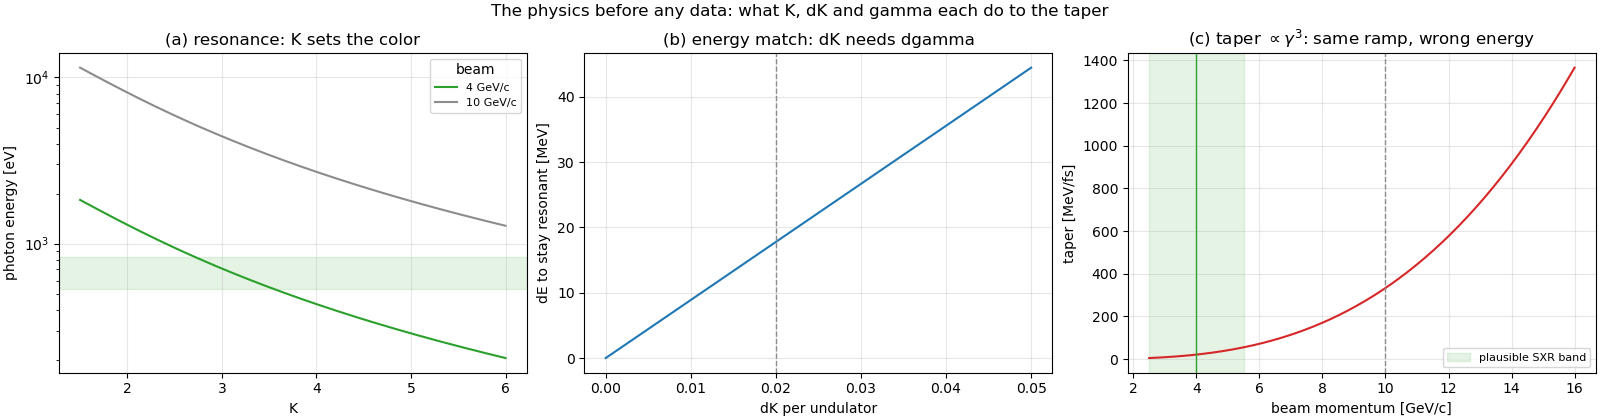

In [1]:
# Interactive figures (zoom/pan).
from IPython import get_ipython
get_ipython().run_line_magic("matplotlib", "widget")
import numpy as np
import matplotlib.pyplot as plt
from taper import dk_to_dgamma, taper_mev_per_fs, gamma_from_momentum_gev

MEC2_MEV = 0.510_998_95          # electron rest energy (dgamma -> MeV)
K0, dK0  = 4.0, 0.02             # a nominal SXR-ish ramp for the illustration
g_nom    = float(gamma_from_momentum_gev(4.0))

fig, (a, b, c) = plt.subplots(1, 3, figsize=(16, 4.2), constrained_layout=True)

# (a) resonance: photon energy fixed by K.  lambda_u is illustrative only (it cancels in the taper).
LAMBDA_U_M = 0.039               # nominal SXR undulator period, for the wavelength axis only
K = np.linspace(1.5, 6.0, 200)
for p_gev, col in [(4.0, "tab:green"), (10.0, "0.55")]:
    g = float(gamma_from_momentum_gev(p_gev))
    lam_r_nm = LAMBDA_U_M * (1 + K**2 / 2) / (2 * g**2) * 1e9
    a.plot(K, 1239.84 / lam_r_nm, color=col, label=f"{p_gev:.0f} GeV/c")   # E[eV] = 1239.84 / lam[nm]
a.axhspan(530, 828, color="tab:green", alpha=0.12)                          # SXR-XLEAP soft band
a.set_yscale("log"); a.set_xlabel("K"); a.set_ylabel("photon energy [eV]")
a.set_title("(a) resonance: K sets the color"); a.legend(title="beam", fontsize=8); a.grid(alpha=0.3)

# (b) a K-ramp demands an energy chirp: dE (per undulator) to stay resonant, vs dK.
dK = np.linspace(0, 0.05, 200)
b.plot(dK, dk_to_dgamma(dK, K0, g_nom) * MEC2_MEV, color="tab:blue")
b.axvline(dK0, color="0.55", ls="--", lw=1)
b.set_xlabel("dK per undulator"); b.set_ylabel("dE to stay resonant [MeV]")
b.set_title("(b) energy match: dK needs dgamma"); b.grid(alpha=0.3)

# (c) THE cubic: same fixed ramp, taper vs beam energy -- why off-nominal energy explodes the taper.
p = np.linspace(2.5, 16, 200)
c.plot(p, taper_mev_per_fs(dK0, K0, gamma_from_momentum_gev(p)), color="tab:red")
c.axvspan(2.5, 5.5, color="tab:green", alpha=0.12, label="plausible SXR band")
c.axvline(4.0, color="tab:green", lw=1); c.axvline(10.0, color="0.55", ls="--", lw=1)
c.set_xlabel("beam momentum [GeV/c]"); c.set_ylabel("taper [MeV/fs]")
c.set_title(r"(c) taper $\propto \gamma^3$: same ramp, wrong energy"); c.legend(fontsize=8); c.grid(alpha=0.3)

fig.suptitle("The physics before any data: what K, dK and gamma each do to the taper")
plt.show()
import matplotlib as _mpl
_mpl.rcParams["figure.max_open_warning"] = 0   # many live interactive figures here; leaks are bounded by num=/clear=True in the loops


## 3. Methods

### 3.1 Data pipeline and the beamline switch

The tool cleanly separates **fetch** from **analysis**:

| module | role |
|---|---|
| `beamlines` | the single line switch (`HXR` / `SXR`); flip `DEFAULT_LINE` there to change lines |
| `snapshots` | fetch binned PV history from the MEME archive into long `snapshots.csv` |
| `taper.constants` | physical constants and the I/O contract (re-exports `DEFAULT_LINE`) |
| `taper.physics` | pure, vectorized taper math |
| `taper.detect` | lasing-group detection (binary erosion / dilation) |
| `taper.store` | long `snapshots.csv` into wide pandas frames |
| `taper.service` | per-time XLEAP timeline assembly |

Both the fetch default PV list and the analysis PV parsing read the same `beamlines.DEFAULT_LINE`, so they cannot disagree. The long CSV `nominal_time, pv, timestamp, value, moved` is the data source of record, with no SQLite or sparklines dependency.

- **$L_u = 3.4$ m** per undulator; inter-undulator drifts are neglected (negligible slippage without the field coupling $\beta_z$ into $\beta_x$).
- **$\gamma$** comes from the active line's dump PV (`BEND:DMPH:400:BACT` on HXR, `BEND:DMPS:400:BACT` on SXR), the beam momentum $p$ in **GeV/c**: $\gamma = \sqrt{(pc)^2+(mc^2)^2}/mc^2$ with $mc^2=0.511$ MeV.
- **$K$** is each undulator's `KAct`; `store.wide_values` pivots the long CSV into a `time x undulator` matrix ordered upstream to downstream.

The setup cell below loads the data and reports the active line.

In [2]:
# Interactive figures (zoom/pan).
from IPython import get_ipython
get_ipython().run_line_magic("matplotlib", "widget")
from datetime import datetime as dt
from pathlib import Path

import numpy as np
import pandas as pd

from taper import (
    SnapshotStore,
    DetectionParams,
    DEFAULT_LINE as LINE,   # active undulator line; flip the ONE switch in beamlines.py
    lasing_kvals,
    first_group,
    gamma_from_momentum_gev,
    dk_to_dgamma,
    taper_mev_per_fs,
    xleap_timeline,
    timeline_frame,
)

print(f"Active line: {LINE.name}   K pattern: {LINE.kact_pattern.pattern}   momentum PV: {LINE.momentum_pv}")

# Load EVERY per-window pull (from scripts/pull_sxr.py) into one store.
PULL_DIR = Path("../data/pulls/sxr")      # notebook cwd = xleap_parser/; adjust if yours differs
paths  = sorted(PULL_DIR.glob("sxr_*.csv"))
frames = [df for p in paths for df in (pd.read_csv(p),) if not df.empty]   # skip empty (pre-LCLS-II) windows
if not frames:
    raise FileNotFoundError(f"no data CSVs in {PULL_DIR.resolve()} -- run scripts/pull_sxr.py first")
merged = pd.concat(frames, ignore_index=True)

merged_path = PULL_DIR.parent / "sxr_all.csv"     # one combined file, reusable (in gitignored data/)
merged.to_csv(merged_path, index=False)
store = SnapshotStore.from_csv(merged_path)

print(f"{len(frames)}/{len(paths)} files had data  ->  {len(store.frame):,} rows, "
      f"{store.frame['nominal_time'].nunique()} time points")
store.frame.head()
import matplotlib as _mpl
_mpl.rcParams["figure.max_open_warning"] = 0   # many live interactive figures here; leaks are bounded by num=/clear=True in the loops


Active line: SXR   K pattern: USEG:UNDS:(\d+):KAct   momentum PV: BEND:DMPS:400:BACT
30/30 files had data  ->  39,497 rows, 1463 time points


### 3.2 Detection: the hockey-stick as a morphological opening

XLEAP is declared when a run of at least **`min_group` = 4** consecutive undulators each step up in $K$ by at least $\rho\cdot\texttt{rho\_scale} = 4\rho$ with $\rho\sim10^{-3}$ (the FEL Pierce parameter). We build the boolean "is this step big enough" mask along the undulator axis, then keep only runs of length $\ge 4$ using **binary erosion followed by dilation**, a morphological *opening*, the vectorized way to say "at least $N$ in a row." The toy example below shows opening discarding the short runs and keeping the length-4 run:

In [3]:
from scipy.ndimage import binary_erosion, binary_dilation


def keep_long_runs(arr, n=4):
    structure = [1] * n
    return binary_dilation(binary_erosion(arr, structure=structure), structure=structure)


keep_long_runs(np.array([0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1], dtype=bool)).astype(int)

array([0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1])

The opening above is illustrated on a toy array; on a real snapshot it looks like this. Panel **(a)** is the *hockey stick* -- a representative clean-XLEAP snapshot's $K$ profile with the detected lasing group highlighted: a flat head, then a monotonic ramp. Panel **(b)** shows the per-undulator step $\Delta K_i$ and which steps clear the $4\rho$ threshold; the morphological opening keeps only the run of $\ge 4$ consecutive qualifying steps, recovering exactly the group highlighted above.

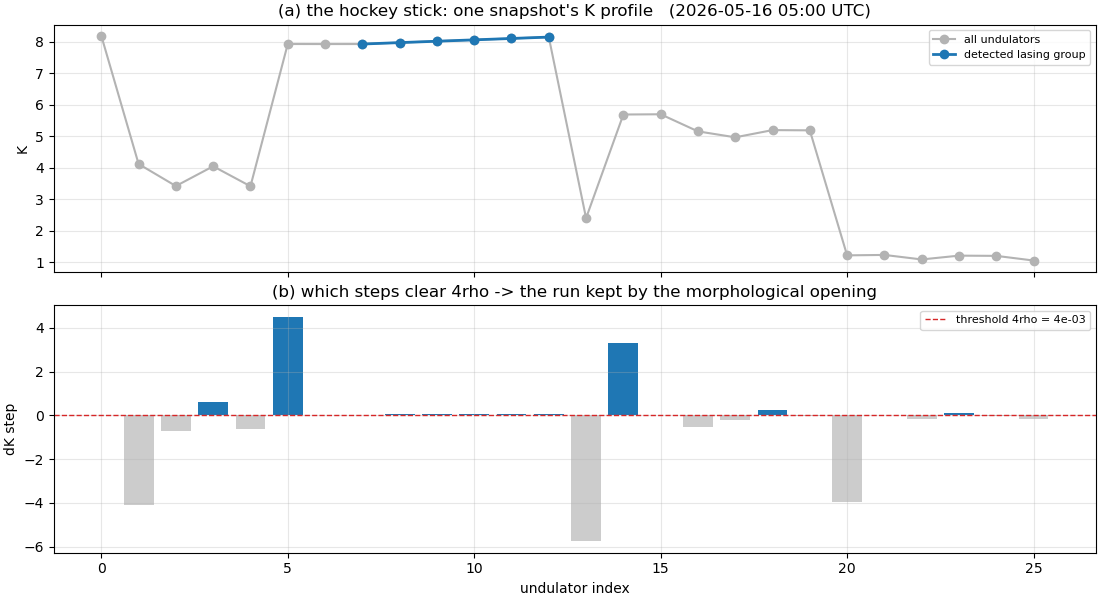

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from taper import DetectionParams, lasing_kvals

params = DetectionParams()
kv   = store.wide_values(LINE.kact_pattern)
pts  = timeline_frame(xleap_timeline(store, line=LINE))
good = pts.index[pts["xleap_on"] & (pts["taper"] < 100)]        # a clean XLEAP snapshot (not an off-energy spike)
t    = good[len(good) // 2]
row    = kv.loc[t]
masked = lasing_kvals(kv, params).loc[t]                        # NaN off the lasing group
dK     = row.diff()
thr    = params.rho * params.rho_scale
keep   = (dK >= thr).fillna(False)

fig, (a, b) = plt.subplots(2, 1, figsize=(11, 6), sharex=True, constrained_layout=True)
x = np.arange(len(row))
a.plot(x, row.values, "o-", color="0.7", label="all undulators")
a.plot(x, masked.values, "o-", color="tab:blue", lw=2, label="detected lasing group")
a.set_ylabel("K"); a.legend(fontsize=8); a.grid(alpha=0.3)
a.set_title(f"(a) the hockey stick: one snapshot's K profile   ({t:%Y-%m-%d %H:%M} UTC)")
b.bar(x, dK.values, color=["tab:blue" if k else "0.8" for k in keep])
b.axhline(thr, color="tab:red", ls="--", lw=1, label=f"threshold 4rho = {thr:.0e}")
b.set_ylabel("dK step"); b.set_xlabel("undulator index"); b.legend(fontsize=8); b.grid(alpha=0.3)
b.set_title(r"(b) which steps clear 4rho -> the run kept by the morphological opening")
plt.show()

`DetectionParams` bundles the thresholds (`rho=1e-3`, `rho_scale=4`, `min_group=4`). `lasing_mask` returns a boolean `time x undulator` frame marking every undulator in a lasing group, including the base undulator just upstream of the first big step (the fencepost correction, since $\Delta K_i$ describes the rise from undulator $i-1$ to $i$, so the group owns one more undulator on its upstream edge). `lasing_kvals` blanks the non-lasing entries to `NaN`.

### 3.3 Taper of a lasing group

For the first (most-upstream) lasing group we take the **median** $\Delta K$ across the group, convert it to $\Delta\gamma$ using the group's first $K$ and the beam $\gamma$, and divide by one undulator's slippage time:
$$
\mathrm{taper} = \frac{\Delta\gamma}{N_u\lambda_r/c} = \frac{2\gamma^2\,\Delta\gamma\,c}{L_u\,(1+K^2/2)}
\qquad\text{(}\texttt{taper\_mev\_per\_fs(dK, K, gamma)}\text{)}.
$$
The **median** rather than the mean makes the estimate robust to the single large step created by the missing undulator slot in the physical lattice.

### 3.4 The K landscape across the full dataset

Before detecting anything, it helps to see the range of $K$ configurations the machine actually used. Per run we overlay **every** snapshot's $K$ profile ($K$ vs undulator, upstream to downstream) as faint lines, with the min-max envelope shaded, the median profile in black, and one clean XLEAP snapshot highlighted. The XLEAP hockey-sticks stand out as ramps climbing the downstream undulators; parked or flat configurations sit as low, level profiles. This is the raw material the detector (Section 3.2) and the taper physics (Section 2) operate on, one profile at a time.

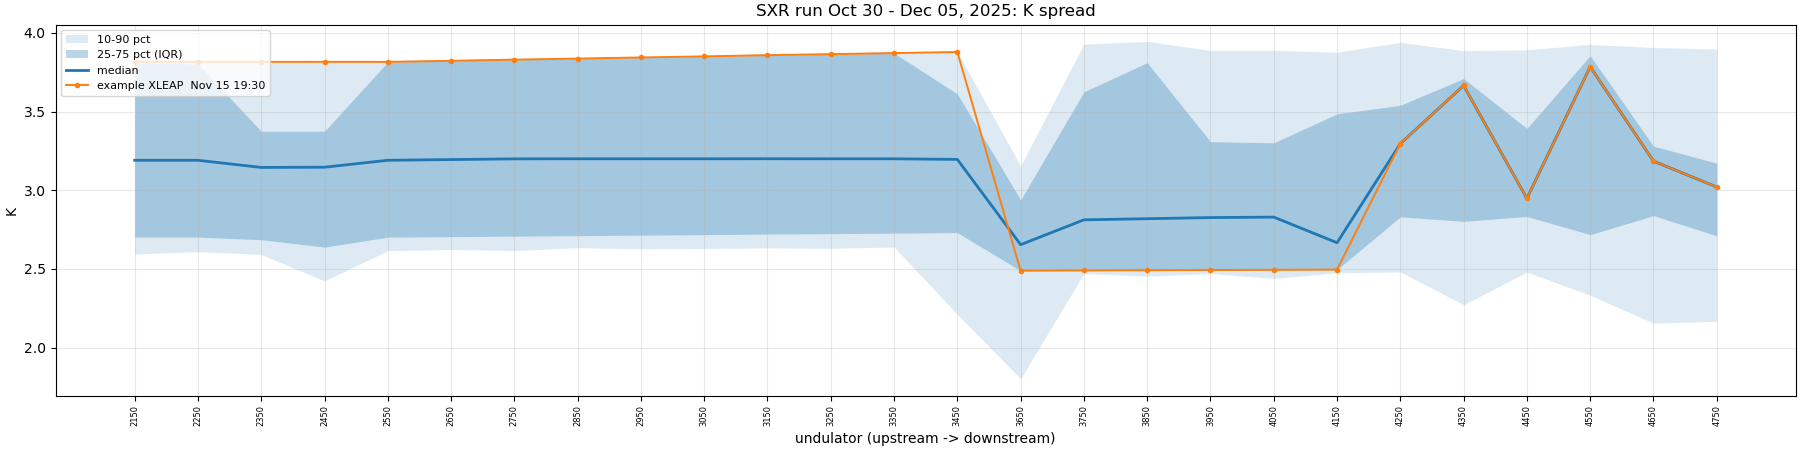

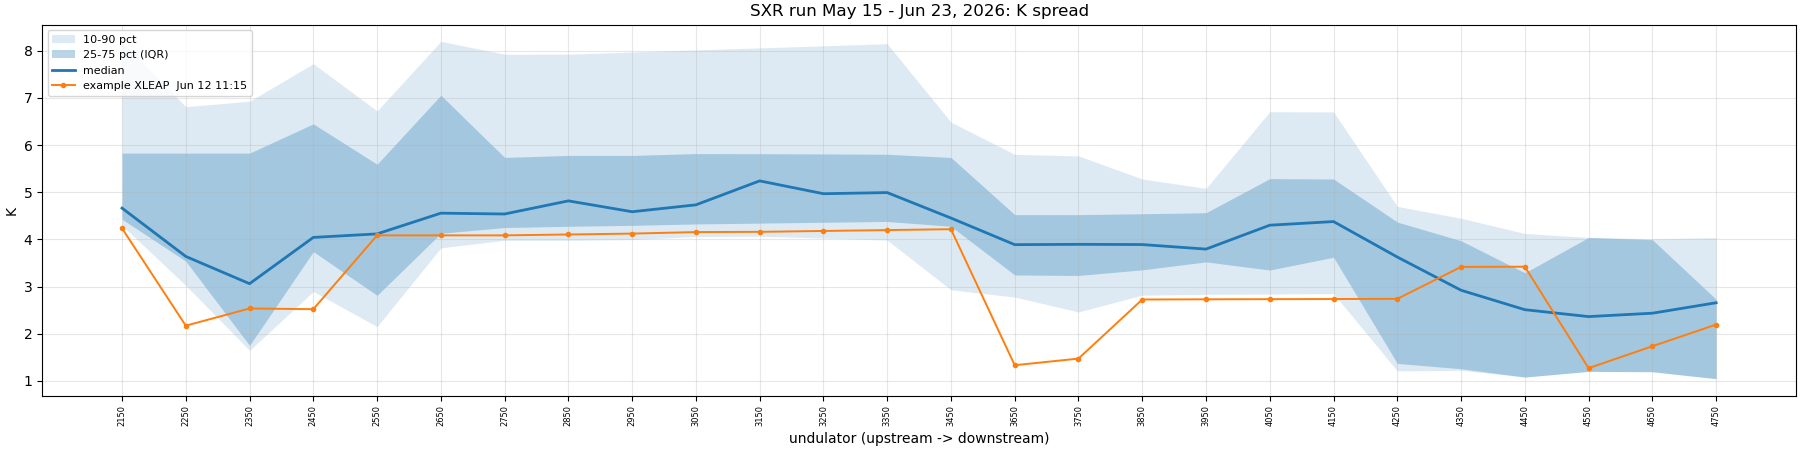

In [5]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

kv  = store.wide_values(LINE.kact_pattern).sort_index()      # time x undulator (upstream..downstream)
pts = timeline_frame(xleap_timeline(store, line=LINE))
PERIOD_GAP = pd.Timedelta("30D")
groups = list(kv.groupby((kv.index.to_series().diff() > PERIOD_GAP).cumsum()))

for i, (_, g) in enumerate(groups):
    V = g.values                                             # (snapshots, undulators)
    x = np.arange(V.shape[1])
    with np.errstate(all="ignore"):
        p10, p25, p50, p75, p90 = (np.nanpercentile(V, q, axis=0) for q in (10, 25, 50, 75, 90))

    fig, ax = plt.subplots(figsize=(18, 4.5), constrained_layout=True,
                           num=f"{LINE.name} K spread run {i}", clear=True)
    ax.fill_between(x, p10, p90, color="tab:blue", alpha=0.15, lw=0, label="10-90 pct")
    ax.fill_between(x, p25, p75, color="tab:blue", alpha=0.30, lw=0, label="25-75 pct (IQR)")
    ax.plot(x, p50, "-", color="tab:blue", lw=2.0, label="median")

    sub = pts.reindex(g.index)                               # one clean XLEAP example from this run
    ex = sub.index[sub["xleap_on"] & (sub["taper"] < 100)]
    if len(ex):
        te = ex[len(ex) // 2]
        ax.plot(x, kv.loc[te].values, "o-", color="tab:orange", ms=3, lw=1.4,
                label=f"example XLEAP  {te:%b %d %H:%M}")

    ax.set_xticks(x); ax.set_xticklabels(g.columns, rotation=90, fontsize=6)
    ax.set_ylabel("K"); ax.set_xlabel("undulator (upstream -> downstream)")
    ax.set_title(f"{LINE.name} run {g.index[0]:%b %d} - {g.index[-1]:%b %d, %Y}: K spread")
    ax.legend(fontsize=8, loc="upper left"); ax.grid(alpha=0.3)
    # TODO animate orange example K profile through the run, with a slider for time; 15-minute intervals | keep blue this is optional so start without | goal is to actually see what the unds are doing for example we have a block where we have lasing unds but no taper so it would be intriguing to see what the unds are doing
    plt.show()

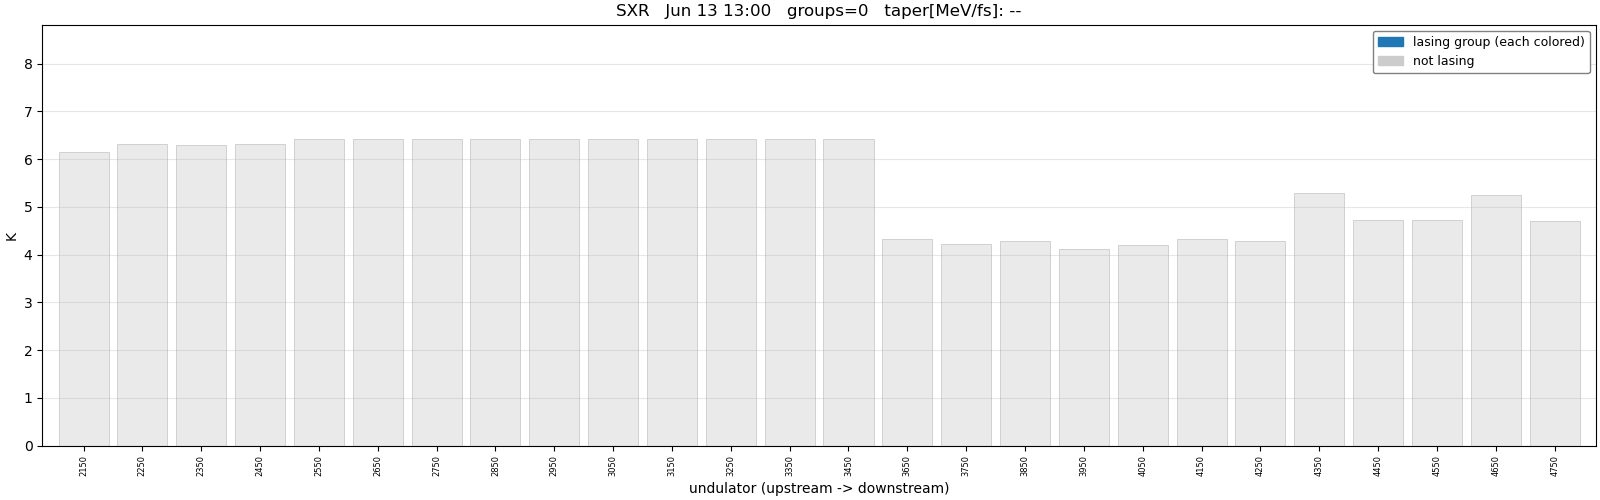

In [6]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import ipywidgets as widgets
from matplotlib.patches import Patch
from IPython.display import display
from taper import DetectionParams, lasing_kvals, taper_mev_per_fs, gamma_from_momentum_gev

START, END = "2026-06-13", "2026-06-17"
STEP, TOL  = pd.Timedelta("15min"), pd.Timedelta("8min")
GCOLORS = plt.cm.tab10(np.arange(10))

kv  = store.wide_values(LINE.kact_pattern).sort_index()
pts = timeline_frame(xleap_timeline(store, line=LINE))
masked_all = lasing_kvals(kv, DetectionParams())

def find_groups(lasing, max_gap=1):                    # contiguous lasing runs (1 missing slot ok)
    idx = np.where(lasing)[0]
    if len(idx) == 0:
        return []
    groups = [[int(idx[0])]]
    for p in idx[1:]:
        if p - groups[-1][-1] <= max_gap + 1:
            groups[-1].append(int(p))
        else:
            groups.append([int(p)])
    return groups

def group_taper(idxs, kk, gamma):                      # same math as the detector, per group
    g = kk[list(idxs)]
    if len(g) < 2 or not np.isfinite(gamma):
        return float("nan")
    return float(taper_mev_per_fs(np.nanmedian(np.diff(g)), g[0], gamma))

def animate(START, END):
    plt.close(f"{LINE.name} und lase")
    kvw = kv.loc[START:END]
    if kvw.empty:
        raise SystemExit(f"no data between {START} and {END}")
    und = list(kvw.columns); x = np.arange(len(und))

    grid = pd.date_range(kvw.index[0].ceil("15min"), kvw.index[-1].floor("15min"), freq=STEP)
    kg   = kvw.reindex(grid, method="nearest", tolerance=TOL)
    mg   = masked_all.reindex(grid, method="nearest", tolerance=TOL)
    momg = store.series(LINE.momentum_pv).reindex(grid, method="nearest", tolerance=TOL)
    keep = kg.notna().any(axis=1); grid = grid[keep]
    kvals, mvals = kg.loc[keep].values, mg.loc[keep].values
    gammas = gamma_from_momentum_gev(momg.loc[keep].values)
    tlabels = [f"{t:%b %d %H:%M}" for t in grid]
    T = len(grid)
    if T == 0:
        raise SystemExit("no 15-min grid points -- widen the range or TOL")
    ymax = np.nanmax(kvals)

    fig, ax = plt.subplots(figsize=(16, 5), constrained_layout=True, num=f"{LINE.name} und lase")
    bars = ax.bar(x, np.nan_to_num(kvals[0]), width=0.85, edgecolor="0.35", lw=0.4)
    ax.set_xticks(x); ax.set_xticklabels(und, rotation=90, fontsize=6)
    ax.set_xlim(-0.7, len(und) - 0.3); ax.set_ylim(0, ymax * 1.25)
    ax.set_ylabel("K"); ax.set_xlabel("undulator (upstream -> downstream)")
    ax.grid(axis="y", alpha=0.3)
    ax.legend(handles=[Patch(color="tab:blue", label="lasing group (each colored)"),
                       Patch(color="0.8", label="not lasing")],
              loc="upper right", fontsize=9, framealpha=1, edgecolor="0.5")

    annos = []
    def update(k):
        kk = kvals[k]; lasing = ~np.isnan(mvals[k])
        groups = find_groups(lasing)
        gid_of = {j: gi for gi, grp in enumerate(groups) for j in grp}
        for a in annos:
            a.remove()
        annos.clear()
        for j, rect in enumerate(bars):
            rect.set_height(kk[j] if np.isfinite(kk[j]) else 0.0)
            if j in gid_of:
                rect.set_facecolor(GCOLORS[gid_of[j] % 10]); rect.set_alpha(1.0)
            else:
                rect.set_facecolor("0.8"); rect.set_alpha(0.4)
        parts = []
        for gi, grp in enumerate(groups):
            tp = group_taper(grp, kk, gammas[k])
            lbl = f"{tp:.0f}" if np.isfinite(tp) else "NaN"
            annos.append(ax.text(np.mean(grp), np.nanmax(kk[grp]) + 0.05 * ymax, lbl,
                                 ha="center", va="bottom", fontsize=8, fontweight="bold",
                                 color=GCOLORS[gi % 10]))
            parts.append(f"g{gi+1}={lbl}")
        ax.set_title(f"{LINE.name}   {tlabels[k]}   groups={len(groups)}   "
                     f"taper[MeV/fs]: {'  '.join(parts) if parts else '--'}")
        fig.canvas.draw_idle()

    update(0)
    slider = widgets.IntSlider(min=0, max=T - 1, value=0, description="t",
                               continuous_update=False, layout=widgets.Layout(width="70%"))
    play = widgets.Play(min=0, max=T - 1, interval=200)
    widgets.jslink((play, "value"), (slider, "value"))
    slider.observe(lambda ch: update(ch["new"]), names="value")
    display(widgets.HBox([play, slider]))
    plt.show()

animate(START, END)

## 4. Results

With the physics fixed (Section 2) and the detector defined (Section 3), we run `xleap_timeline(store, line=LINE)` over the whole fetched SXR window. It returns one `XleapPoint` per nominal time -- `{datetime, xleap_on, K_lasing, n_und, taper, moving, energy_unsteady, energy_implausible}`. We assemble the picture one layer at a time: first ask whether the taper tracks the lasing count, then resolve the run structure, then bring in the beam energy -- which is where the story turns.

### 4.1 Does the taper track the lasing count?

The most basic check: overlay the taper (blue, left) and the number of lasing undulators (orange, right) across the window. Where a tapered lasing group exists the two move together; motion-flagged points are force-cleared to `taper = NaN`. A clean band near $\sim20$ MeV/fs is real XLEAP; the isolated spikes up to $\sim730$ MeV/fs are the anomaly the rest of the paper explains.

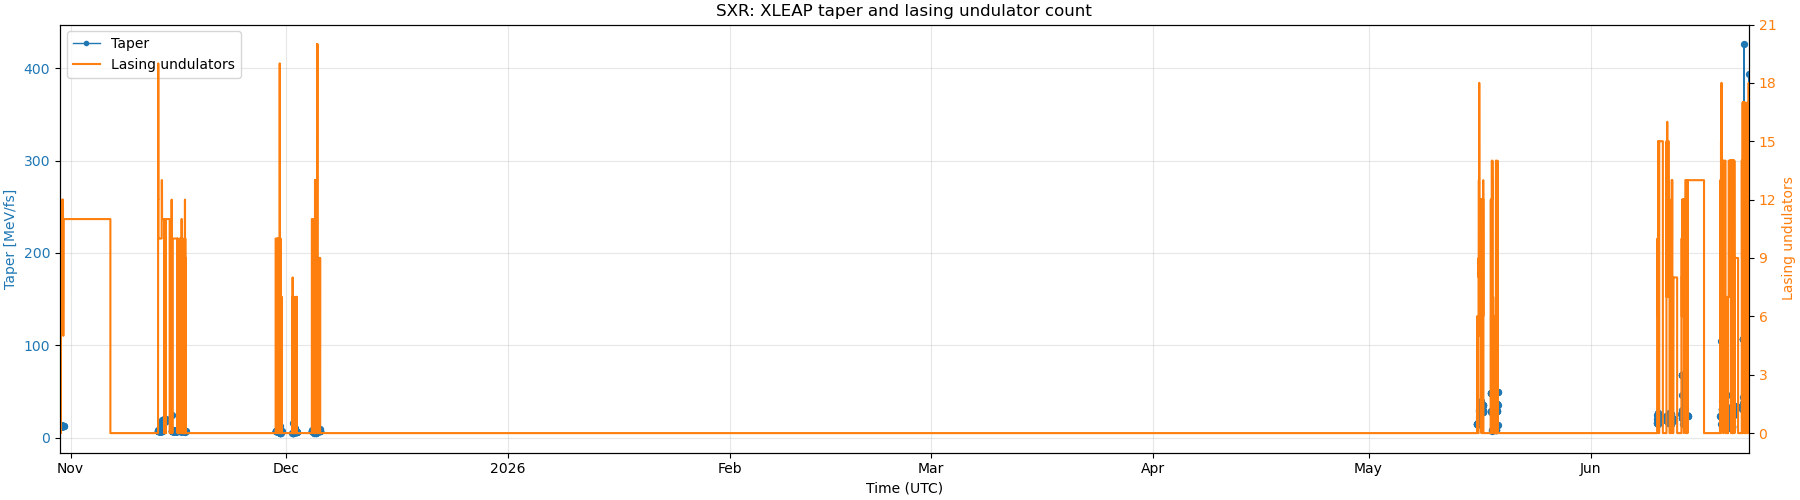

In [7]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import MaxNLocator

points   = xleap_timeline(store, line=LINE)
xleap_df = timeline_frame(points)

def plot_comparison(taper_ax, df, title, xlo=None, xhi=None):
    """Taper + lasing-undulator dual-axis view on one Axes."""
    und_ax = taper_ax.twinx()
    mask = df["xleap_on"]
    taper_ax.plot(df.index, df["taper"], marker="o", ms=3, lw=1, color="tab:blue", label="Taper")
    und_ax.step(df.index, df["n_und"], where="mid", lw=1.5, color="tab:orange", label="Lasing undulators")
    if mask.any():
        taper_ax.scatter(df.index[mask], df.loc[mask, "taper"], s=18, color="tab:blue", zorder=3)
    taper_ax.set_xlim(xlo or df.index.min(), xhi or df.index.max())
    taper_ax.set_title(title)
    taper_ax.set_ylabel("Taper [MeV/fs]", color="tab:blue")
    und_ax.set_ylabel("Lasing undulators", color="tab:orange")
    und_ax.yaxis.set_major_locator(MaxNLocator(integer=True))
    taper_ax.tick_params(axis="y", labelcolor="tab:blue")
    und_ax.tick_params(axis="y", labelcolor="tab:orange")
    taper_ax.grid(True, alpha=0.3)
    loc = mdates.AutoDateLocator()
    taper_ax.xaxis.set_major_locator(loc)
    taper_ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(loc))
    lines = taper_ax.get_lines() + und_ax.get_lines()
    taper_ax.legend(lines, [ln.get_label() for ln in lines], loc="upper left")

fig, ax = plt.subplots(figsize=(18, 5), constrained_layout=True)
plot_comparison(ax, xleap_df, f"{LINE.name}: XLEAP taper and lasing undulator count")
ax.set_xlabel("Time (UTC)")
plt.show()

### 4.2 Per run, on a real time axis

Rather than pack every session onto an artificial index and collapse the gaps -- which makes the x-axis unreadable -- we split on gaps longer than 30 days and draw **one figure per run** on a genuine UTC time axis. The idle stretches between sessions stay as real gaps, and with the interactive backend enabled above you can zoom straight into any lasing block. Same two quantities (taper blue, lasing orange), now one legible panel per run.

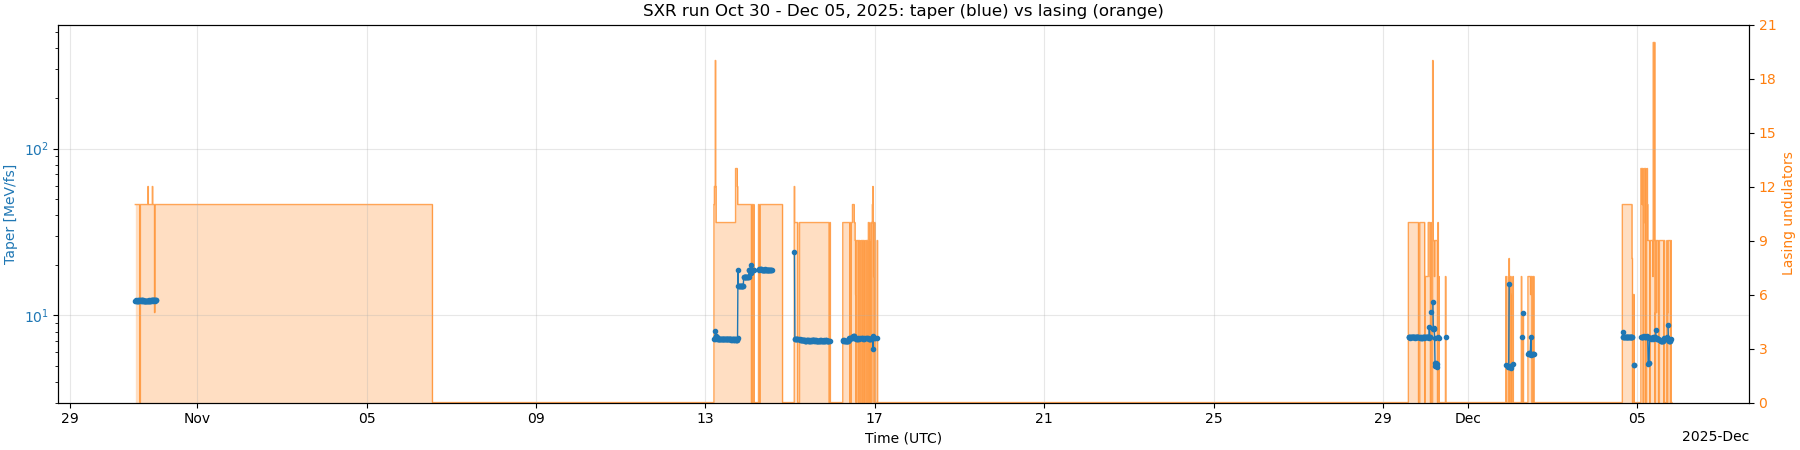

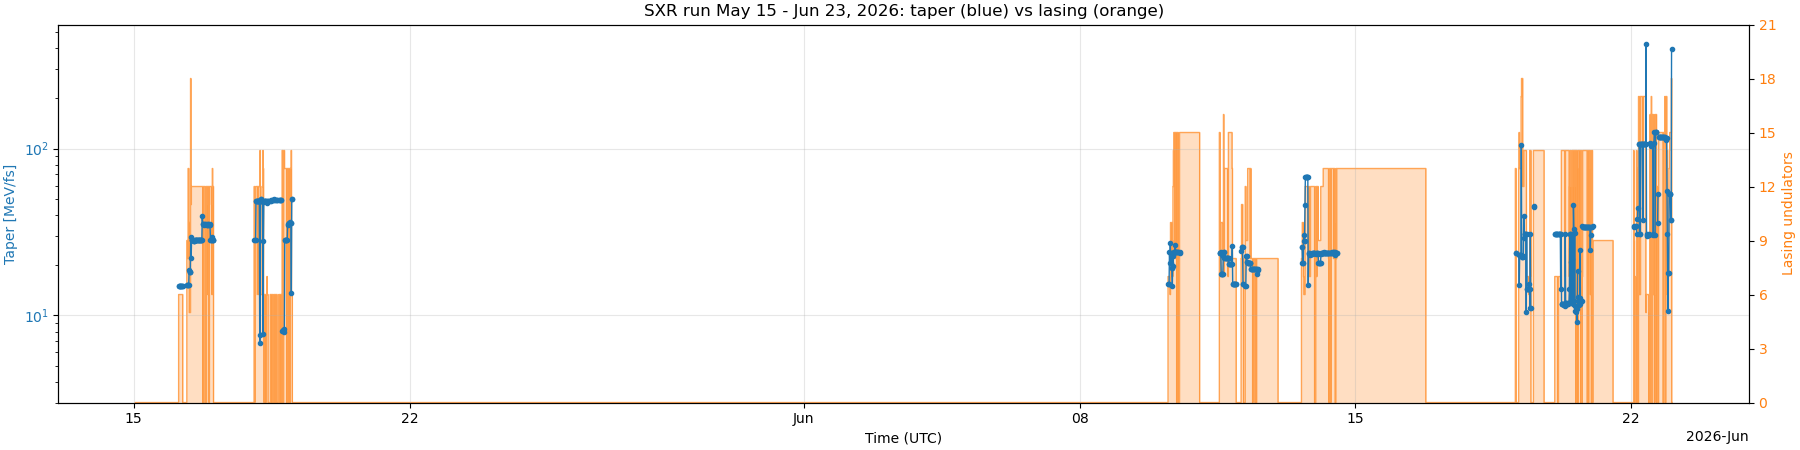

In [8]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import MaxNLocator

df = timeline_frame(xleap_timeline(store, line=LINE)).sort_index()
PERIOD_GAP = pd.Timedelta("30D")                      # split on the long shutdown; one figure per run
periods = [g for _, g in df.groupby((df.index.to_series().diff() > PERIOD_GAP).cumsum())]
tmax = np.nanmax(df["taper"]); umax = int(df["n_und"].max()) + 1

for i, g in enumerate(periods):
    fig, ax_t = plt.subplots(figsize=(18, 4.5), constrained_layout=True,
                             num=f"{LINE.name} 4.2 run {i}", clear=True)   # reuse on re-run, no leak
    und = ax_t.twinx()
    und.fill_between(g.index, g["n_und"].fillna(0), step="mid", color="tab:orange", alpha=0.25, lw=0)
    und.step(g.index, g["n_und"], where="mid", color="tab:orange", lw=1.0, alpha=0.7)
    ax_t.plot(g.index, g["taper"], "o-", color="tab:blue", ms=3, lw=1)
    ax_t.set_yscale("log"); ax_t.set_ylim(3, tmax * 1.3)
    und.set_ylim(0, umax); und.yaxis.set_major_locator(MaxNLocator(integer=True))
    ax_t.set_zorder(und.get_zorder() + 1); ax_t.patch.set_visible(False)
    ax_t.set_ylabel("Taper [MeV/fs]", color="tab:blue"); ax_t.tick_params(axis="y", labelcolor="tab:blue")
    und.set_ylabel("Lasing undulators", color="tab:orange"); und.tick_params(axis="y", labelcolor="tab:orange")
    loc = mdates.AutoDateLocator(); ax_t.xaxis.set_major_locator(loc)
    ax_t.xaxis.set_major_formatter(mdates.ConciseDateFormatter(loc))
    ax_t.grid(True, alpha=0.3); ax_t.set_xlabel("Time (UTC)")
    ax_t.set_title(f"{LINE.name} run {g.index[0]:%b %d} - {g.index[-1]:%b %d, %Y}: "
                   f"taper (blue) vs lasing (orange)")
    plt.show()

### 4.3 Adding the third number: beam energy

The taper depends on three inputs -- $K$, $\Delta K$, and $\gamma$ -- but so far we have only watched the undulators. Overlaying the beam energy (green, top axis) on the same per-run, real-time panels completes the picture: lasing undulators (orange, back), taper (blue, middle, log), energy (green, top). The clean XLEAP band sits near $\sim20$ MeV/fs at $\sim4$ GeV/c, and every large taper excursion coincides with the green trace jumping away. Given the $\gamma^3$ scaling of Section 2.1, that alignment is the whole explanation.

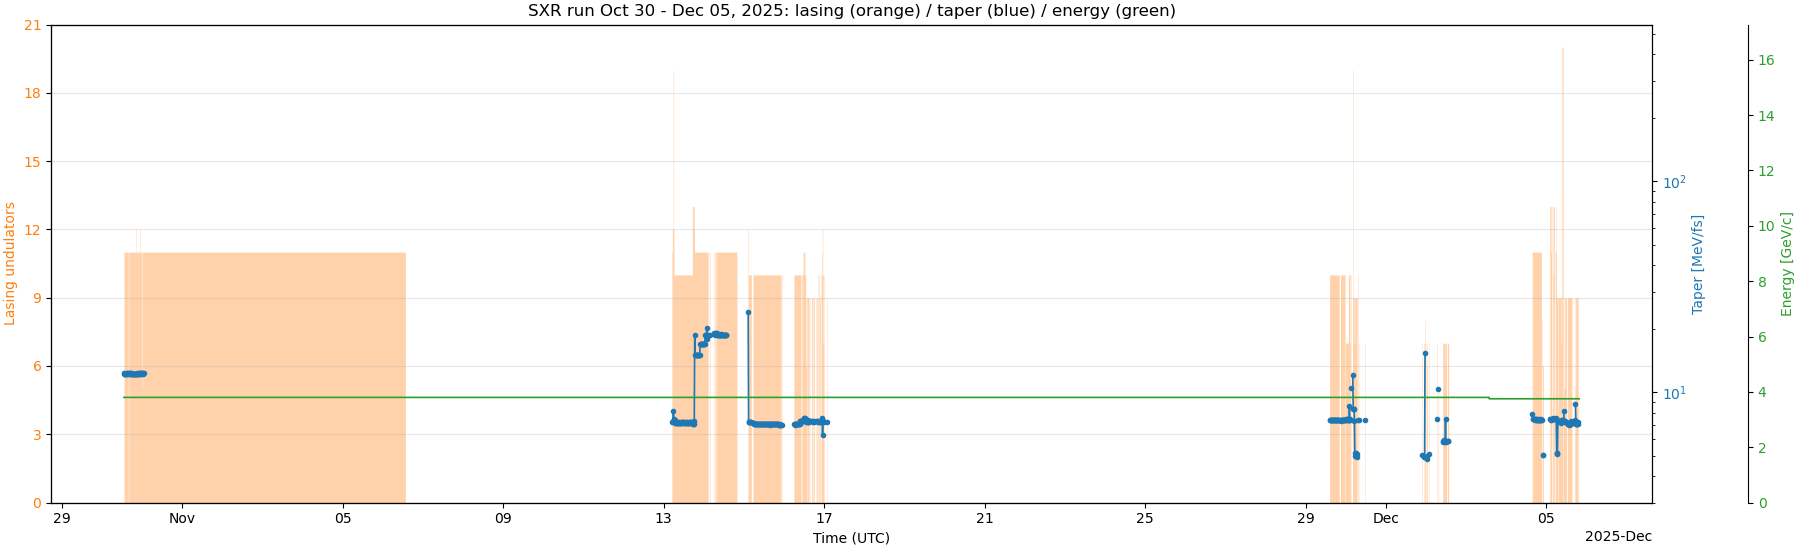

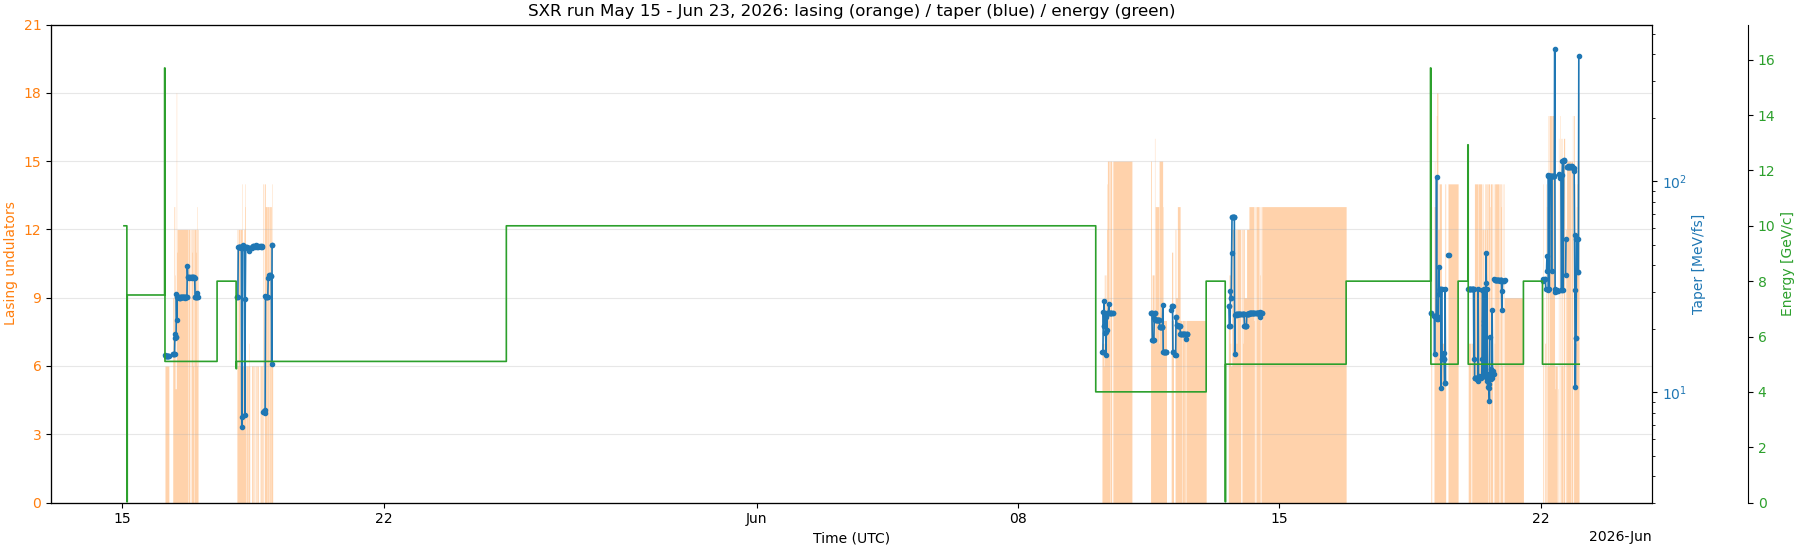

In [9]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import MaxNLocator

df = timeline_frame(xleap_timeline(store, line=LINE)).sort_index()
df["energy"] = store.series(LINE.momentum_pv).reindex(df.index)
PERIOD_GAP = pd.Timedelta("30D")
periods = [g for _, g in df.groupby((df.index.to_series().diff() > PERIOD_GAP).cumsum())]
tmax = np.nanmax(df["taper"]); umax = int(df["n_und"].max()) + 1; emax = np.nanmax(df["energy"]) * 1.1

for i, g in enumerate(periods):
    fig, ax_u = plt.subplots(figsize=(18, 5.5), constrained_layout=True,
                             num=f"{LINE.name} 4.3 run {i}", clear=True)   # reuse on re-run, no leak
    ax_t = ax_u.twinx(); ax_e = ax_u.twinx()
    ax_e.spines["right"].set_position(("axes", 1.06))
    ax_u.set_zorder(1); ax_t.set_zorder(2); ax_e.set_zorder(3)          # lasing back / taper mid / energy top
    ax_t.patch.set_visible(False); ax_e.patch.set_visible(False)

    ax_u.fill_between(g.index, g["n_und"].fillna(0), step="mid", color="tab:orange", alpha=0.35, lw=0)
    ax_u.set_ylim(0, umax); ax_u.yaxis.set_major_locator(MaxNLocator(integer=True))
    ax_t.plot(g.index, g["taper"], "o-", color="tab:blue", ms=3, lw=1.2)
    ax_t.set_yscale("log"); ax_t.set_ylim(3, tmax * 1.3)
    ax_e.plot(g.index, g["energy"], color="tab:green", lw=1.2, drawstyle="steps-mid")
    ax_e.set_ylim(0, emax)

    ax_u.set_ylabel("Lasing undulators", color="tab:orange"); ax_u.tick_params(axis="y", labelcolor="tab:orange")
    ax_t.set_ylabel("Taper [MeV/fs]", color="tab:blue"); ax_t.tick_params(axis="y", labelcolor="tab:blue")
    ax_e.set_ylabel("Energy [GeV/c]", color="tab:green"); ax_e.tick_params(axis="y", labelcolor="tab:green")
    loc = mdates.AutoDateLocator(); ax_u.xaxis.set_major_locator(loc)
    ax_u.xaxis.set_major_formatter(mdates.ConciseDateFormatter(loc))
    ax_u.grid(True, axis="y", alpha=0.3); ax_u.set_xlabel("Time (UTC)")
    ax_u.set_title(f"{LINE.name} run {g.index[0]:%b %d} - {g.index[-1]:%b %d, %Y}: "
                   f"lasing (orange) / taper (blue) / energy (green)")
    plt.show()

### 4.4 Aligned view and operator clearing

Three overlaid axes are compact but crowded, so we unstack them into three aligned rows sharing a real time axis, one figure per run. Every interval the quality gates flag as off-nominal or operator clearing (`energy_implausible` / `energy_unsteady`) is shaded red across all three rows, and the plausible SXR band ($2.5$ to $5.5$ GeV/c) is marked on the energy row. Almost every taper spike sits inside a red interval -- the beam was between working points, not lasing at a genuine taper. Section 5 proves it quantitatively.

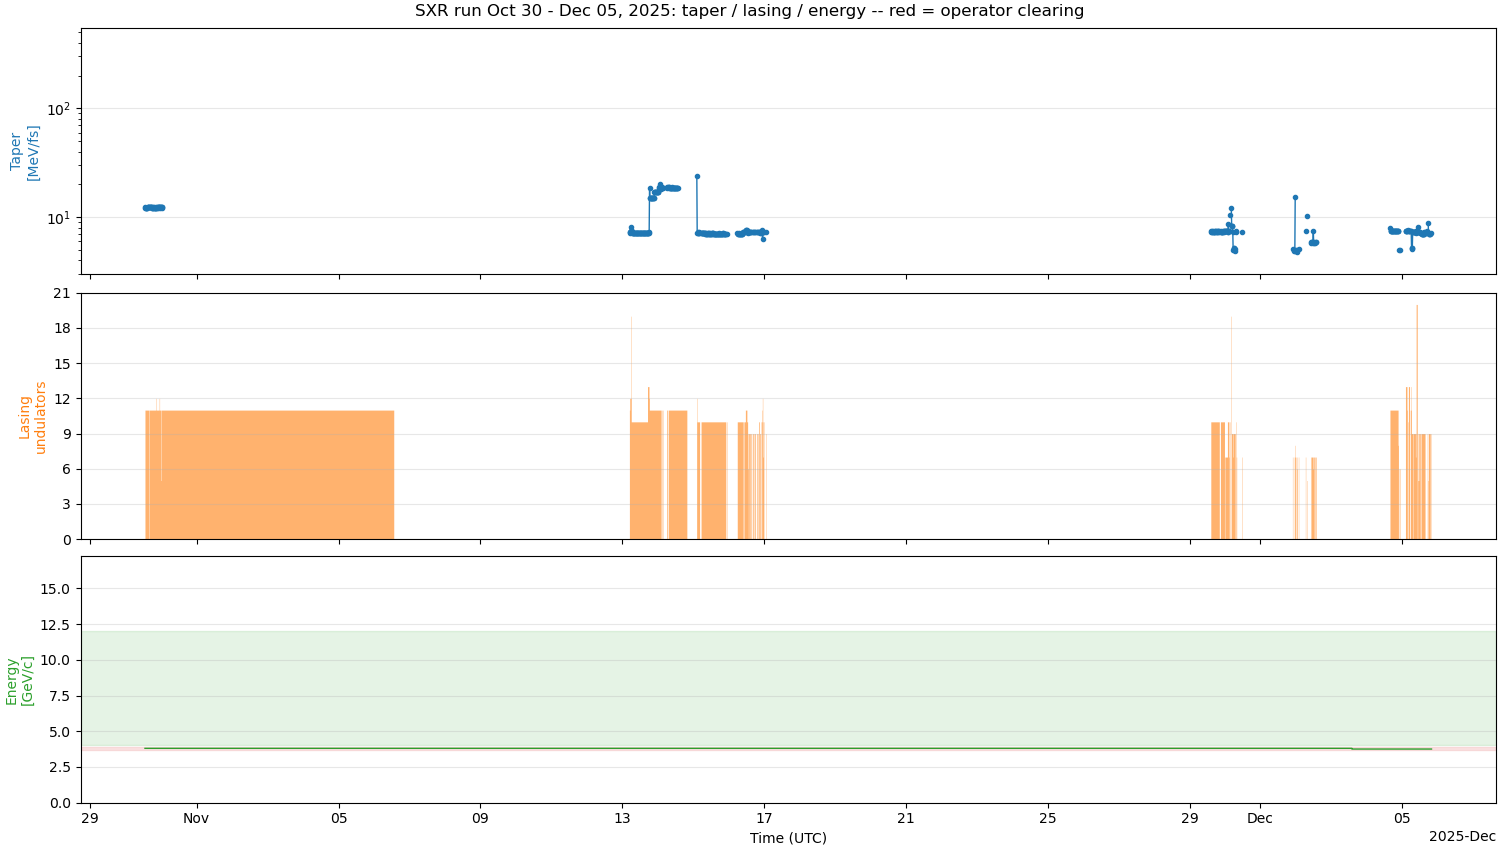

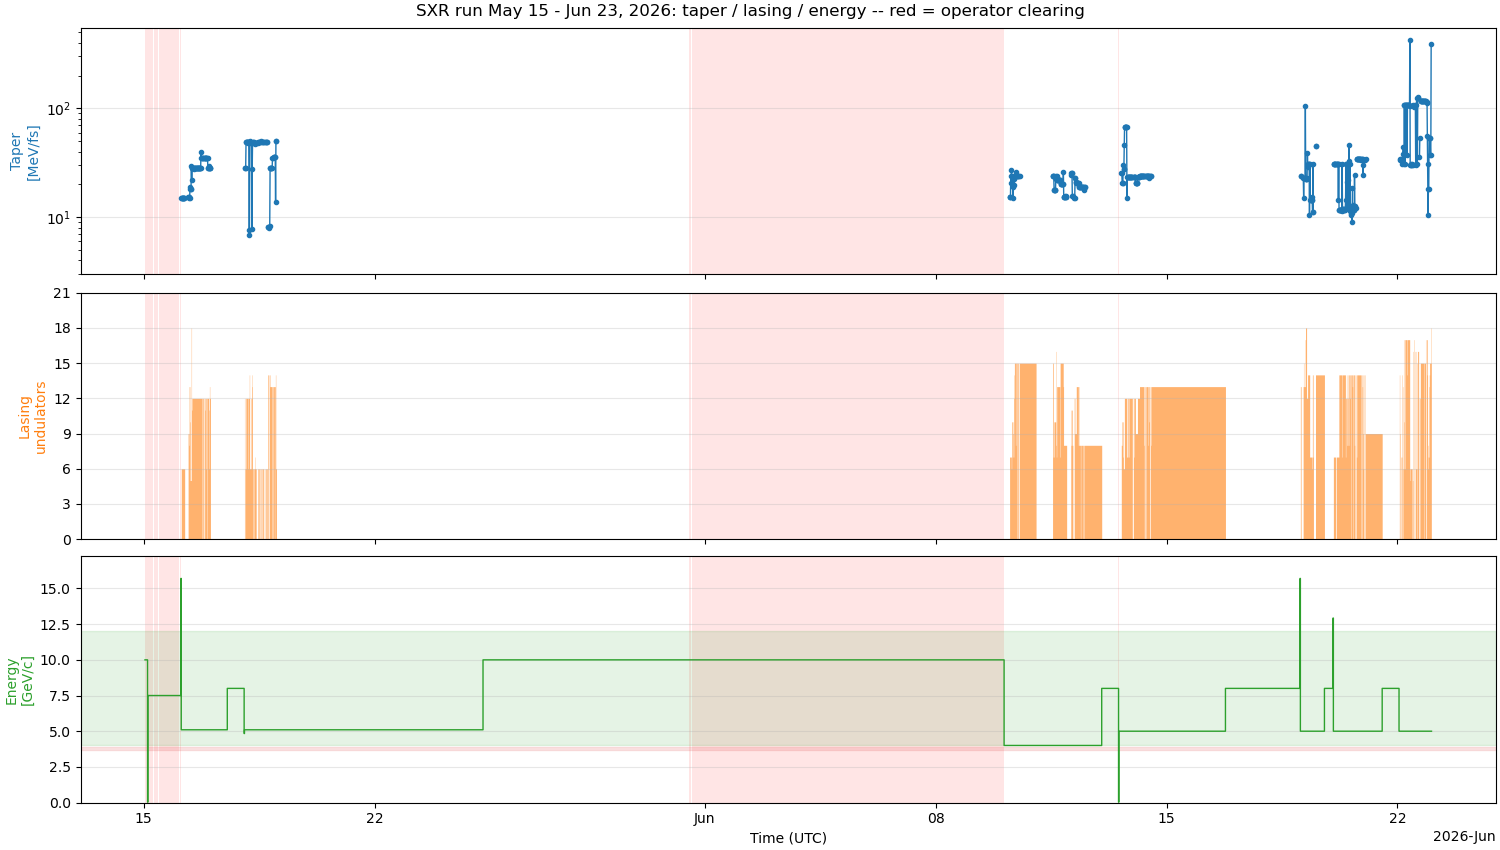

In [10]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import MaxNLocator

df = timeline_frame(xleap_timeline(store, line=LINE)).sort_index()
df["energy"]   = store.series(LINE.momentum_pv).reindex(df.index)
df["clearing"] = df["energy_implausible"] | df["energy_unsteady"]   # operator clearing / off-nominal
PERIOD_GAP = pd.Timedelta("30D")
periods = [g for _, g in df.groupby((df.index.to_series().diff() > PERIOD_GAP).cumsum())]
tmax = np.nanmax(df["taper"]); umax = int(df["n_und"].max()) + 1; emax = np.nanmax(df["energy"]) * 1.1

for i, g in enumerate(periods):
    fig, (axt, axu, axe) = plt.subplots(3, 1, figsize=(15, 8.5), sharex=True, constrained_layout=True,
                                        num=f"{LINE.name} 4.4 run {i}", clear=True)   # reuse on re-run
    for ax in (axt, axu, axe):                                    # red = clearing, on all three rows
        ax.fill_between(g.index, 0, 1, where=g["clearing"].fillna(False),
                        transform=ax.get_xaxis_transform(), color="red", alpha=0.10, lw=0)
    axt.plot(g.index, g["taper"], "o-", color="tab:blue", ms=3, lw=1)
    axt.set_yscale("log"); axt.set_ylim(3, tmax * 1.3); axt.set_ylabel("Taper\n[MeV/fs]", color="tab:blue")
    axu.fill_between(g.index, g["n_und"].fillna(0), step="mid", color="tab:orange", alpha=0.6, lw=0)
    axu.set_ylim(0, umax); axu.yaxis.set_major_locator(MaxNLocator(integer=True))
    axu.set_ylabel("Lasing\nundulators", color="tab:orange")
    axe.plot(g.index, g["energy"], color="tab:green", lw=1, drawstyle="steps-mid")
    ax.axhspan(4, 12, color="tab:green", alpha=0.12); axe.set_ylim(0, emax)   # plausible band
    ax.axhspan(3.65, 3.9, color="tab:red", alpha=0.12);axe.set_ylim(0, emax)   # operator clearing band
    axe.set_ylabel("Energy\n[GeV/c]", color="tab:green")
    for ax in (axt, axu, axe): ax.grid(True, axis="y", alpha=0.3)
    loc = mdates.AutoDateLocator(); axe.xaxis.set_major_locator(loc)
    axe.xaxis.set_major_formatter(mdates.ConciseDateFormatter(loc)); axe.set_xlabel("Time (UTC)")
    fig.suptitle(f"{LINE.name} run {g.index[0]:%b %d} - {g.index[-1]:%b %d, %Y}: "
                 f"taper / lasing / energy -- red = operator clearing")
    plt.show()

## 5. Validation and investigation

The June 2026 SXR timeline shows a clean $\sim20$ MeV/fs XLEAP band plus a handful of extreme spikes up to $\sim730$ MeV/fs. This section establishes what those spikes are, confirms the motion filter neither misses real motion nor discards real XLEAP, and settles the motion-threshold choice with data.

The cell below builds the "with filter" (`after`) and "without filter" (`before`) timelines from the same data (the latter by forcing every `moved` flag to `False`), so we can see exactly what the motion filter removes.

In [11]:
import dataclasses

after   = timeline_frame(xleap_timeline(store, line=LINE))                                     # filter ON
before  = timeline_frame(xleap_timeline(
    dataclasses.replace(store, frame=store.frame.assign(moved=False)), line=LINE))             # filter OFF
kvals   = store.wide_values(LINE.kact_pattern)
moved   = store.wide_moved(LINE.kact_pattern)
mom     = store.series(LINE.momentum_pv).reindex(after.index)
removed = before.index[before["xleap_on"] & ~after["xleap_on"]]

print(f"snapshots           : {len(after)}")
print(f"XLEAP-on (filtered) : {int(after['xleap_on'].sum())}")
print(f"moved cells total   : {int(store.frame['moved'].sum())}")
print(f"times any-moving    : {int(moved.any(axis=1).sum())} / {len(moved)}")
print(f"removed by filter   : {len(removed)}")

snapshots           : 1463
XLEAP-on (filtered) : 963
moved cells total   : 923
times any-moving    : 132 / 1463
removed by filter   : 109


### 5.1 Motion filter: rule and effect

**Motion rule (per Aaron).** For each nominal time an undulator has *moved* when the fractional spread of its raw samples inside a 5 s window exceeds a threshold $\tau$:
$$
\frac{\max - \min}{\lvert\mathrm{median}\rvert} > \tau \quad(\tau = 10^{-3}),\qquad \le 1\ \text{sample} \Rightarrow \text{stationary (thermal noise)}.
$$
If **any** undulator moved at a given time, that time is force-cleared: `xleap_on = False`, `taper = NaN`, `moving = True`, kept visible rather than dropped.

The figure overlays **before** (motion off, grey) and **after** (motion on, blue/orange); red crosses mark points the filter removed. A correct filter removes only slew/transition points and leaves the stable lasing blocks, and crucially the large spikes, untouched.

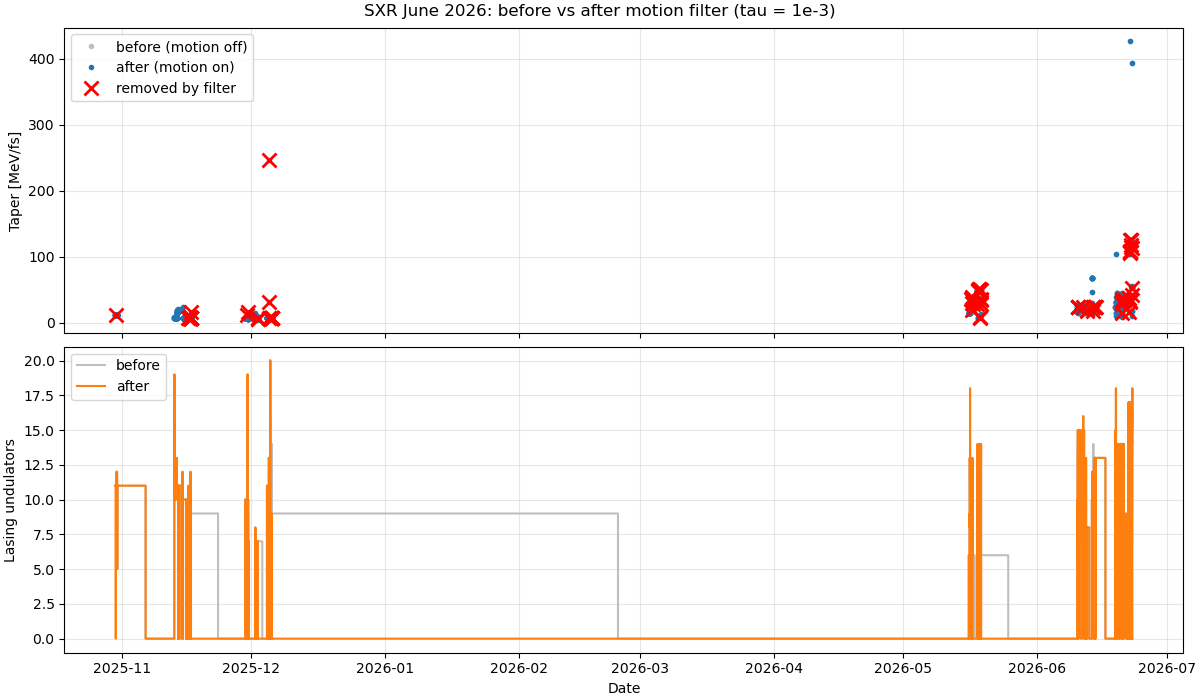

In [12]:
fig, (ax_t, ax_n) = plt.subplots(2, 1, figsize=(12, 7), sharex=True, constrained_layout=True)
ax_t.plot(before.index, before["taper"], "o", ms=3, color="0.75", label="before (motion off)")
ax_t.plot(after.index,  after["taper"],  "o", ms=3, color="tab:blue", label="after (motion on)")
if len(removed):
    ax_t.plot(removed, before.loc[removed, "taper"], "x", color="red", ms=10, mew=2, label="removed by filter")
ax_t.set_ylabel("Taper [MeV/fs]"); ax_t.grid(alpha=0.3); ax_t.legend(loc="upper left")
ax_n.step(before.index, before["n_und"], where="mid", color="0.75", label="before")
ax_n.step(after.index,  after["n_und"],  where="mid", color="tab:orange", label="after")
ax_n.set_ylabel("Lasing undulators"); ax_n.set_xlabel("Date"); ax_n.grid(alpha=0.3); ax_n.legend(loc="upper left")
fig.suptitle(f"{LINE.name} June 2026: before vs after motion filter (tau = 1e-3)")
plt.show()

**Observation.** The red crosses land only on the normal $\sim20$ MeV/fs band, at the edges of lasing blocks, where undulators are slewing in or out of a configuration. The large spikes carry no red cross: the motion filter does not touch them. That is the first clue that the spikes are not a motion phenomenon.

### 5.2 The largest spike is stationary, not moving

We drill into the single worst point. Its summary and full $K$ profile follow.

In [13]:
sp = after["taper"].idxmax()
display(pd.DataFrame({
    "time": [sp],
    "taper [MeV/fs]": [round(float(after.loc[sp, "taper"]), 1)],
    "beam [GeV/c]": [round(float(mom.loc[sp]), 3)],
    "n_und": [int(after.loc[sp, "n_und"])],
    "moving": [bool(after.loc[sp, "moving"])],
}))

,time,taper [MeV/fs],beam [GeV/c],n_und,moving
0,2026-06-22 09:00:00,426.2,5.0,5,False


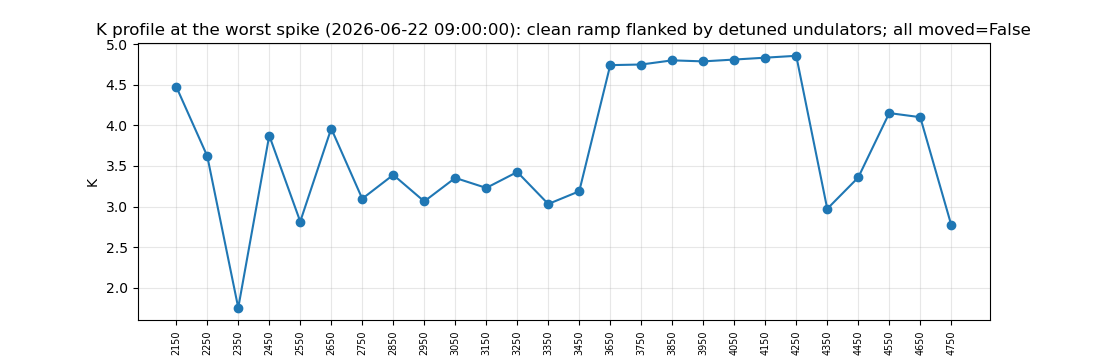

In [14]:
ks = kvals.loc[sp]
fig, ax = plt.subplots(figsize=(11, 3.6))
ax.plot(range(len(ks)), ks.values, "o-")
ax.set_xticks(range(len(ks))); ax.set_xticklabels(ks.index, rotation=90, fontsize=7)
ax.set_ylabel("K"); ax.set_xlabel("undulator")
ax.set_title(f"K profile at the worst spike ({sp}): clean ramp flanked by detuned undulators; all moved=False")
ax.grid(alpha=0.3); plt.show()

**The profile tells the whole story.** A clean, monotonic $K$-ramp occupies the middle undulators (here $K\approx5.3$), but it is flanked by heavily detuned undulators ($K$ roughly 1 to 3.7) that are clearly parked, not lasing. Every undulator reports `moved = False`: the Ks are stationary. This is Aaron's "Ks in place, but the beam energy wasn't there yet." A 5 s motion window can never flag it, because there is no motion to flag. We verified separately that even a 10 times tighter threshold ($\tau=10^{-4}$) leaves this point `moving = False`.

### 5.3 The spikes correlate with off-nominal beam energy

If the spikes are a beam-energy artefact, they should occur when the machine is not at the soft line's normal operating energy. Splitting the XLEAP-on points by taper magnitude and summarising the beam momentum confirms it, and the scatter makes the $\gamma^3$ inflation visible.

In [15]:
on = after["xleap_on"]
tbl = pd.concat({
    "real (taper <= 100)":    mom[on & (after["taper"] <= 100)].describe(),
    "spurious (taper > 100)": mom[on & (after["taper"] >  100)].describe(),
}, axis=1)
display(tbl.round(2))

,real (taper <= 100),spurious (taper > 100)
count,920.00,43.0
mean,4.31,5.0
std,0.60,0.0
min,3.75,5.0
25%,3.80,5.0
50%,4.00,5.0
75%,5.00,5.0
max,5.10,5.0


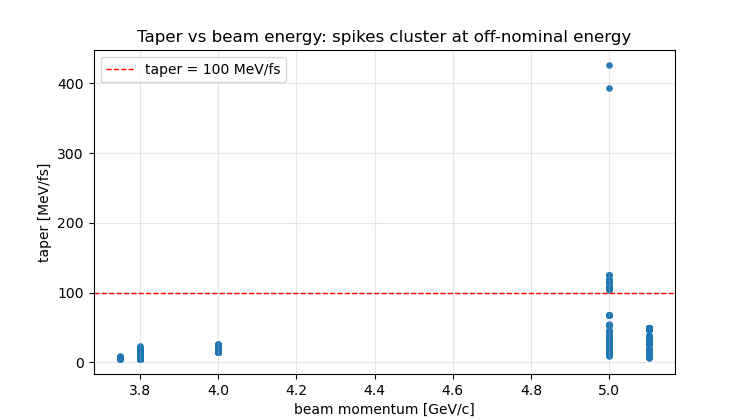

In [16]:
fig, ax = plt.subplots(figsize=(7.5, 4.2))
ax.scatter(mom[on], after["taper"][on], s=14, color="tab:blue")
ax.axhline(100, color="red", ls="--", lw=1, label="taper = 100 MeV/fs")
ax.set_xlabel("beam momentum [GeV/c]"); ax.set_ylabel("taper [MeV/fs]")
ax.set_title("Taper vs beam energy: spikes cluster at off-nominal energy")
ax.grid(alpha=0.3); ax.legend()
plt.show()

**Result.** The real XLEAP band sits in a tight 4 to 5 GeV/c cluster; the $>100$ MeV/fs spikes occur at 5 to 15.7 GeV/c (median about 8). Combined with the $\gamma^3$ scaling of Section 2.1, an ordinary $\Delta K\approx0.02$, $K\approx4$ to $5$ ramp inflates into hundreds of MeV/fs. The spikes are detection false positives in an off-nominal beam state, not motion, and not a taper-math error.

Note the overlap: the spurious set reaches down to 5 GeV/c and the real set up to 10 GeV/c, and XLEAP legitimately runs at 8 to 10 GeV. A flat energy cut or a flat taper ceiling would therefore clip real high-energy XLEAP; the correct discriminator is a resonance/energy-match condition (Section 6).

To see the beam energy *directly* around each taper spike, we pull the raw (unbinned) dump-momentum PV over the May-June run in a single archive query and slice it into short zoom windows keyed to the spike times (run this on the SLAC network). The top panel is the full-run context with each zoom window shaded; the grid below resolves what the 900 s bin cannot -- a steady off-nominal plateau, or the operator *clearing the line* (the dump magnet swinging the energy through a standardization sine). The plausible SXR band (2.5 to 5.5 GeV/c) is shaded on every panel.

loaded 20,678,977 samples from cache (BEND_DMPS_400_BACT_20251001-20260622.pkl)
33,332 high-swing samples -> 33 sine events (steps rejected)


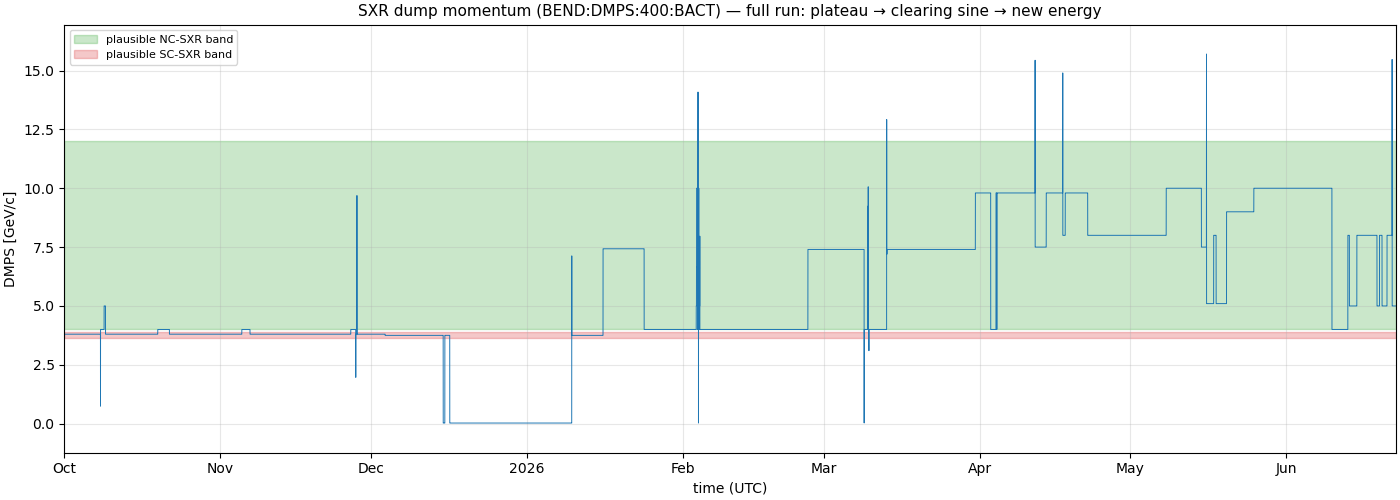

In [20]:
from datetime import datetime, timezone
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import meme.archive


def utc(y, m, d, hh, mm=0):
    return datetime(y, m, d, hh, mm, tzinfo=timezone.utc)


PV = LINE.momentum_pv
t0, t1 = utc(2025, 10, 1, 0, 0), utc(2026, 6, 22, 19, 0)

# --- fetch once (monthly chunks so nothing truncates), cache to disk ---
REFETCH   = False
CACHE_DIR = Path("cache"); CACHE_DIR.mkdir(exist_ok=True)
CACHE     = CACHE_DIR / f"{PV.replace(':', '_')}_{t0:%Y%m%d}-{t1:%Y%m%d}.pkl"

if CACHE.exists() and not REFETCH:
    s = pd.read_pickle(CACHE)
    print(f"loaded {len(s):,} samples from cache ({CACHE.name})")
else:
    bounds = list(pd.date_range(t0, t1, freq="MS", tz="UTC"))
    bounds = [t0] + [b for b in bounds if t0 < b < t1] + [t1]
    parts = []
    for a, b in zip(bounds[:-1], bounds[1:]):
        df = meme.archive.get_dataframe(PV, from_time=a.to_pydatetime(), to_time=b.to_pydatetime())
        print(f"  {a:%Y-%m-%d} -> {b:%Y-%m-%d}: {len(df):,} rows")
        if len(df):
            parts.append(df)
    raw = pd.concat(parts)
    raw.index = raw.index.tz_convert("UTC")
    raw = raw[~raw.index.duplicated()].sort_index()
    s = raw.iloc[:, 0]
    s.to_pickle(CACHE)
    print(f"cached {len(s):,} samples")

# --- auto-pick zoom windows on SINE bursts, rejecting stair-steps ---
SWING         = 3.0                    # GeV/c peak-to-peak within WIN to flag a burst
WIN           = "5min"                 # timescale of the burst
GAP           = pd.Timedelta("20min")  # merge bursts closer than this into one event
PAD           = pd.Timedelta("3min")   # tight crop -> the oscillation fills the panel
MIN_CROSSINGS = 3                      # midline crossings to count as a WAVE (a step crosses once)

rng = s.rolling(WIN, center=True).max() - s.rolling(WIN, center=True).min()
hot = s.index[(rng > SWING).fillna(False)]

def is_wave(b):
    """True if the burst oscillates (sine) rather than making a single stair-step."""
    span = b.max() - b.min()
    if span <= 0:
        return False
    sign = np.sign(b.values - (b.max() + b.min()) / 2)
    sign = sign[sign != 0]
    return sign.size >= 2 and int((np.diff(sign) != 0).sum()) >= MIN_CROSSINGS

events = []
if len(hot):
    grp = (hot.to_series().diff() > GAP).cumsum()
    for _, t in hot.to_series().groupby(grp):
        if not is_wave(s.loc[t.iloc[0]:t.iloc[-1]]):
            continue
        lo = max(t.iloc[0] - PAD, s.index.min())
        hi = min(t.iloc[-1] + PAD, s.index.max())
        if len(s.loc[lo:hi]):
            events.append((lo, hi))
events.sort()

windows = [(f"{lo:%b %d %H:%M}", lo, hi) for lo, hi in events]   # <- consumed by cells 2 & 3
colors  = plt.cm.turbo(np.linspace(0.05, 0.95, max(1, len(windows))))
if not windows:
    raise SystemExit("no sine bursts found -- lower SWING or MIN_CROSSINGS")
print(f"{len(hot):,} high-swing samples -> {len(windows)} sine events (steps rejected)")

# --- full-run context ---
mpl.rcParams["path.simplify"] = False       # keep every plotted point (renders the full span cleanly)

fig, ax = plt.subplots(figsize=(14, 5), constrained_layout=True, clear=True)
try:
    fig.canvas.header_visible = False
    fig.canvas.toolbar_position = "bottom"
except Exception:
    pass

step = max(1, len(s) // 20000)              # thin the overview; detection still uses full-res s
ax.plot(s.index[::step], s.values[::step], lw=0.7, color="tab:blue", rasterized=True)
ax.axhspan(4, 12, color="tab:green", alpha=0.25, label="plausible NC-SXR band")
ax.axhspan(3.65, 3.9, color="tab:red", alpha=0.25, label="plausible SC-SXR band")
ax.set_xlim(s.index.min(), s.index.max())
ax.margins(y=0.08)
ax.set_title(f"{LINE.name} dump momentum ({PV}) — full run: plateau → clearing sine → new energy",
             fontsize=11)
ax.set_xlabel("time (UTC)")
ax.set_ylabel("DMPS [GeV/c]")
ax.grid(alpha=0.3)
ax.legend(loc="upper left", fontsize=8)
loc = mdates.AutoDateLocator()
ax.xaxis.set_major_locator(loc)
ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(loc))
plt.show()

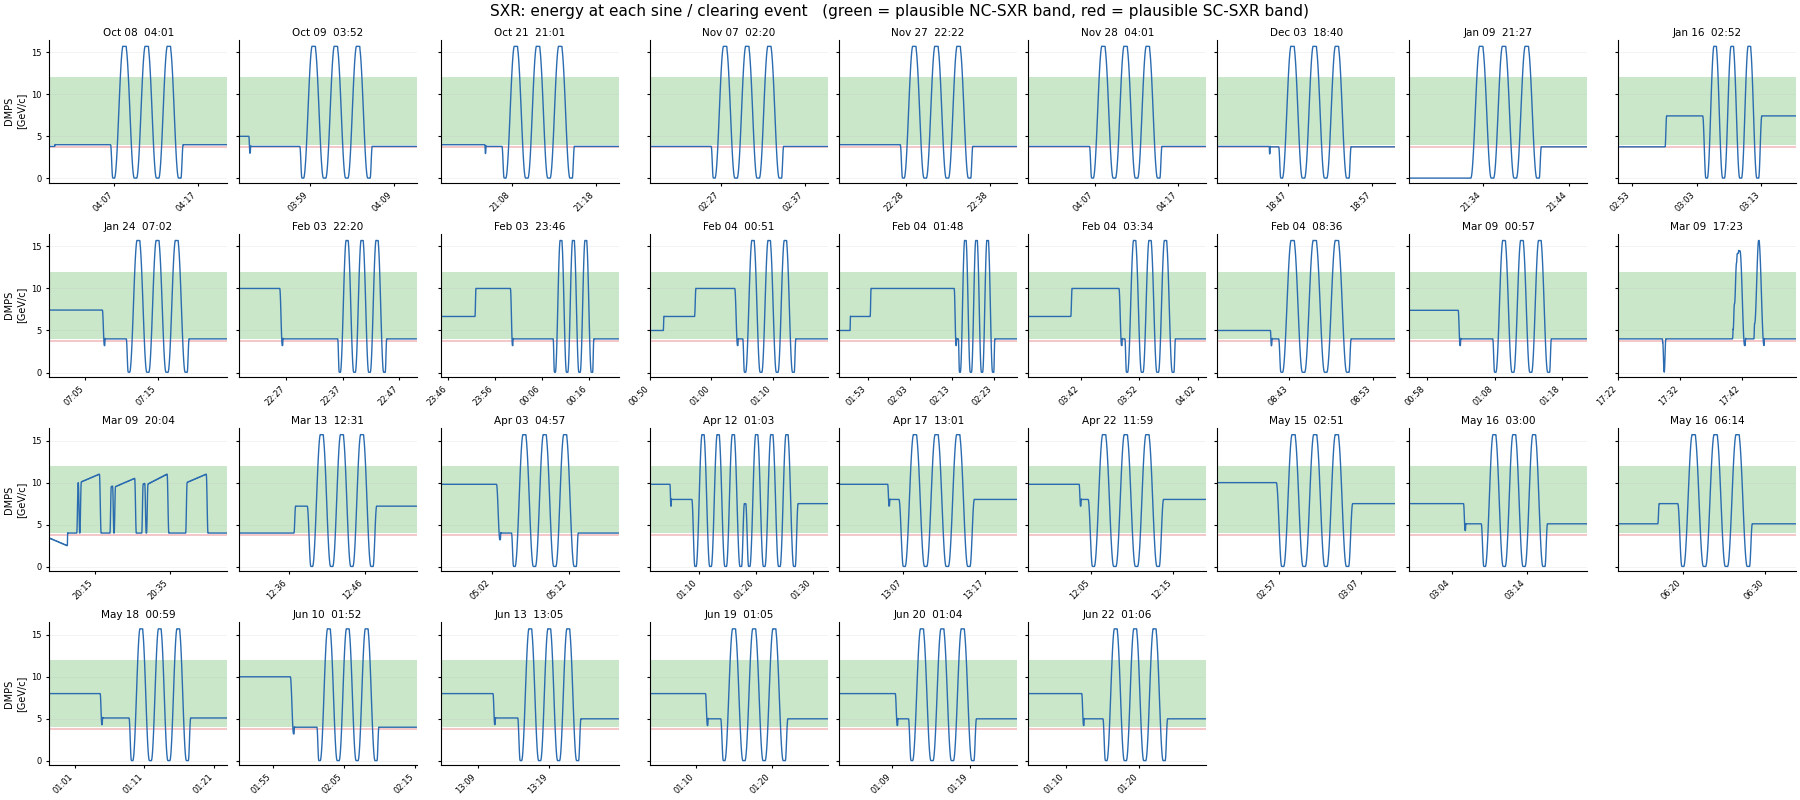

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

LEAD       = pd.Timedelta("2min")          # small lead-in -> wave fills the panel
LINE_COLOR = "#2b6cb0"                      # one color reads cleaner than the turbo rainbow

def time_locator(z):
    mins = (z.index[-1] - z.index[0]).total_seconds() / 60
    if   mins <= 8:   return mdates.MinuteLocator(interval=2)
    elif mins <= 20:  return mdates.MinuteLocator(interval=5)
    elif mins <= 45:  return mdates.MinuteLocator(interval=10)
    elif mins <= 90:  return mdates.MinuteLocator(interval=20)
    elif mins <= 180: return mdates.MinuteLocator(interval=30)
    else:             return mdates.HourLocator()

ncol = 9
nrow = int(np.ceil(len(windows) / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(2.0 * ncol, 2.0 * nrow),
                         constrained_layout=True, sharey=True, squeeze=False,
                         num=f"{LINE.name} energy spike zoom", clear=True)
axes = axes.ravel()

for k, ((name, zlo, zhi), c) in enumerate(zip(windows, colors)):        # one panel per sine event
    ax = axes[k]
    z = s.loc[zlo - LEAD:zhi]
    ax.axhspan(4, 12, color="tab:green", alpha=0.25, lw=0)
    ax.axhspan(3.65, 3.9, color="tab:red", alpha=0.25, lw=0)
    ax.plot(z.index, z.values, lw=1.0, color=LINE_COLOR, solid_capstyle="round")
    ax.set_title(f"{zlo:%b %d  %H:%M}", fontsize=7.5, pad=3)
    ax.set_ylim(-0.5, 16.5); ax.set_yticks([0, 5, 10, 15])
    ax.margins(x=0)
    ax.grid(axis="y", alpha=0.2, lw=0.5)
    ax.tick_params(labelsize=6, length=2)
    ax.xaxis.set_major_locator(time_locator(z))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
    for lbl in ax.get_xticklabels():
        lbl.set_rotation(45); lbl.set_ha("right")
    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)

for r in range(nrow):                       # y-label once per row (sharey hides inner ticks)
    axes[r * ncol].set_ylabel("DMPS\n[GeV/c]", fontsize=7)

for ax in axes[len(windows):]:              # hide unused trailing panels
    ax.set_visible(False)

fig.suptitle(f"{LINE.name}: energy at each sine / clearing event   (green = plausible NC-SXR band, red = plausible SC-SXR band)",
             fontsize=11)
plt.show()

In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

LEAD       = pd.Timedelta("2min")          # match the on-screen wave view
LINE_COLOR = "#2b6cb0"
OUT        = Path(f"{LINE.name}_energy_spike_windows_ALL.png")   # saved next to the notebook

def time_locator(z):
    mins = (z.index[-1] - z.index[0]).total_seconds() / 60
    if   mins <= 8:   return mdates.MinuteLocator(interval=2)
    elif mins <= 20:  return mdates.MinuteLocator(interval=5)
    elif mins <= 45:  return mdates.MinuteLocator(interval=10)
    elif mins <= 90:  return mdates.MinuteLocator(interval=20)
    elif mins <= 180: return mdates.MinuteLocator(interval=30)
    else:             return mdates.HourLocator()

ncol = 4
nrow = int(np.ceil(len(windows) / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(4.0 * ncol, 2.4 * nrow),
                         constrained_layout=True, sharey=True, squeeze=False)
axes = axes.ravel()

for k, ((name, zlo, zhi), c) in enumerate(zip(windows, colors)):
    ax = axes[k]
    z = s.loc[zlo - LEAD:zhi]
    ax.axhspan(2.5, 5.5, color="tab:green", alpha=0.08, lw=0)
    ax.plot(z.index, z.values, lw=1.0, color=LINE_COLOR, solid_capstyle="round")
    ax.set_title(f"{zlo:%b %d  %H:%M}", fontsize=8, pad=3)
    ax.set_ylim(-0.5, 16.5); ax.set_yticks([0, 5, 10, 15])
    ax.margins(x=0)
    ax.grid(axis="y", alpha=0.2, lw=0.5)
    ax.tick_params(labelsize=7, length=2)
    ax.xaxis.set_major_locator(time_locator(z))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
    for lbl in ax.get_xticklabels():
        lbl.set_rotation(45); lbl.set_ha("right")
    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)
    if k % ncol == 0:
        ax.set_ylabel("DMPS [GeV/c]", fontsize=8)

for ax in axes[len(windows):]:
    ax.set_visible(False)

fig.suptitle(f"{LINE.name}: energy at each sine / clearing event  (green = plausible SXR band)", fontsize=12)
fig.savefig(OUT, dpi=130, bbox_inches="tight")
plt.close(fig)                     # write the file, don't render inline
print("saved:", OUT.resolve())

saved: /sdf/group/cds/sw/epics/users/mamais/xleap_project/xleap_fel_research/xleap_parser/SXR_energy_spike_windows_ALL.png


### 5.4 Motion-threshold study: $10^{-3}$ vs $10^{-4}$

David asked whether the motion threshold should be $10^{-3}$ or $10^{-4}$. Each value is baked into the `moved` column at fetch time, so the two rows below come from separate fetches and are recorded here as constants (they are not recomputed from the currently-loaded CSV). Both thresholds remove only real-band points, never the spikes.

In [ ]:
sweep = pd.DataFrame([
    {"threshold": "1e-3 (recommended)", "removed": 25, "real_XLEAP_removed": 25,
     "isolated_transitions": 18, "in_runs": 6, "note": "only slew/transition points removed"},
    {"threshold": "1e-4",               "removed": 33, "real_XLEAP_removed": 33,
     "isolated_transitions": None, "in_runs": None, "note": "8 extra removals are sub-0.1%, i.e. thermal"},
])
display(sweep)

,threshold,removed,real_XLEAP_removed,isolated_transitions,in_runs,note
0,1e-3 (recommended),25,25,18.0,6.0,only slew/transition points removed
1,1e-4,33,33,NaN,NaN,"8 extra removals are sub-0.1%, i.e. thermal"


**Decision: $\tau = 10^{-3}$.** Going to $10^{-4}$ removes 8 additional real XLEAP points, and by construction those 8 have fractional change between $10^{-4}$ and $10^{-3}$, i.e. sub-$0.1\%$, squarely in the thermal-noise regime the rule is meant to ignore. So $10^{-4}$ starts labelling thermal jitter as motion and eats real XLEAP; $10^{-3}$ removes only the clearly-moving points.

At $10^{-3}$ the 25 removals split into 18 isolated transitions (clean) and 6 that fall in short consecutive runs. The latter are real-band XLEAP points ($n_\text{und}=7$ to 15, taper 14 to 25) removed because an undulator crossed threshold at that moment, rule-consistent but a small, non-zero loss worth flagging:

In [ ]:
in_runs = pd.DataFrame([
    ("2026-06-10 12:30", 15, 23.6), ("2026-06-10 12:45", 15, 23.9),
    ("2026-06-13 23:30",  7, 23.5), ("2026-06-13 23:45", 14, 18.4),
    ("2026-06-14 12:00",  9, 24.5), ("2026-06-20 17:30", 14, 14.2),
], columns=["time", "n_und_before", "taper_before"])
display(in_runs)

,time,n_und_before,taper_before
0,2026-06-10 12:30,15,23.6
1,2026-06-10 12:45,15,23.9
2,2026-06-13 23:30,7,23.5
3,2026-06-13 23:45,14,18.4
4,2026-06-14 12:00,9,24.5
5,2026-06-20 17:30,14,14.2


## 6. Full picture: the gated XLEAP timeline

Putting it together: the detector finds tapered lasing groups, and the three quality gates (`moving`, `energy_unsteady`, `energy_implausible`) force-clear the configurations where the taper is untrustworthy. What survives is the physical XLEAP taper -- a tight band, not a spray of spikes. The timeline below keeps only gated XLEAP points; the histogram at right shows the distribution collapsing onto the $\sim20$ MeV/fs band that Section 2's physics predicts for a normal SXR working point.

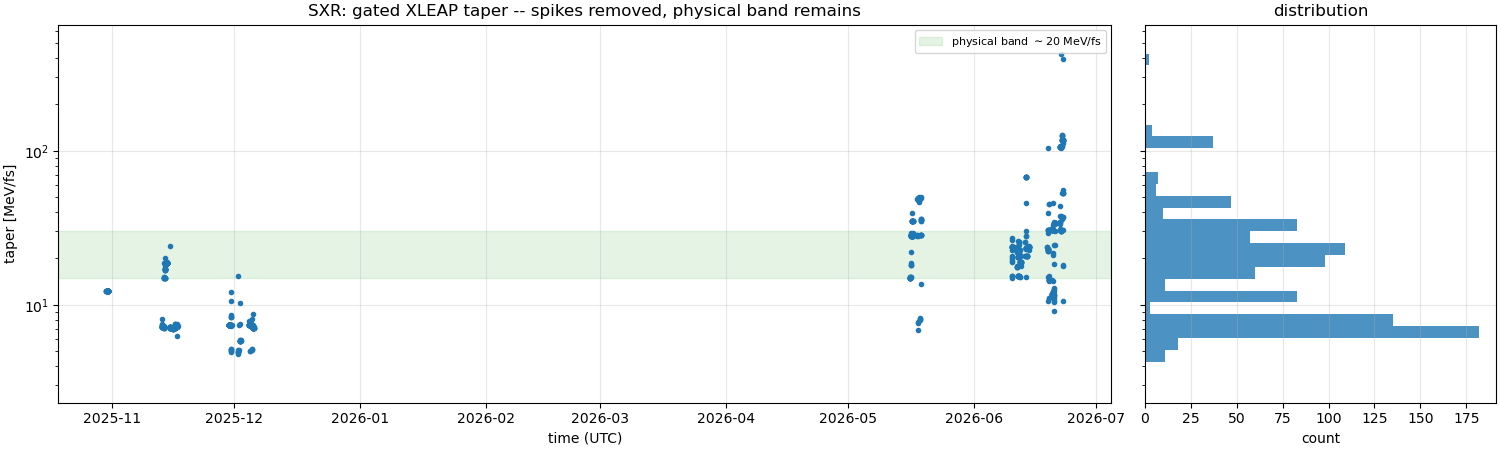

gated XLEAP points: 963   median taper: 15.5 MeV/fs


In [22]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

df = timeline_frame(xleap_timeline(store, line=LINE)).sort_index()
gated = df[df["xleap_on"] & ~df["energy_implausible"] & ~df["energy_unsteady"] & ~df["moving"]]

fig, (ax, axh) = plt.subplots(1, 2, figsize=(15, 4.5), constrained_layout=True,
                              gridspec_kw={"width_ratios": [3, 1]}, sharey=True)
ax.plot(gated.index, gated["taper"], "o", ms=3, color="tab:blue")
ax.axhspan(15, 30, color="tab:green", alpha=0.12, label=r"physical band $\sim$20 MeV/fs")
ax.set_yscale("log"); ax.set_ylabel("taper [MeV/fs]"); ax.set_xlabel("time (UTC)")
ax.set_title(f"{LINE.name}: gated XLEAP taper -- spikes removed, physical band remains")
ax.legend(loc="upper right", fontsize=8); ax.grid(alpha=0.3)
tvals = gated["taper"].dropna()
axh.hist(tvals, bins=np.logspace(np.log10(3), np.log10(tvals.max()*1.2), 30),
         orientation="horizontal", color="tab:blue", alpha=0.8)
axh.set_xlabel("count"); axh.set_title("distribution"); axh.grid(alpha=0.3)
plt.show()
print(f"gated XLEAP points: {len(gated)}   median taper: {tvals.median():.1f} MeV/fs")

## 7. Discussion and open questions

**What is settled.**
- The pipeline reconstructs XLEAP, the lasing undulators, and the taper, and reproduces the reference SXR results.
- The motion filter works: at $\tau=10^{-3}$ it removes 25 points (18 isolated transitions and 6 real-band points during genuine undulator motion) and loses no stable XLEAP.
- The high-taper spikes are not motion (stationary Ks at any threshold) but detection false positives at off-nominal beam energy, amplified by the $\gamma^3$ dependence.

**Open questions (for David).**
1. **Resonance / energy-match gate.** Reject "Ks tapered but beam not at the lasing energy." It must still admit real 8 to 10 GeV XLEAP, so it cannot be a flat energy or taper cap. Natural form: require the group's $K$ to be near the resonant $K$ for the measured $\gamma$ and target photon energy (needs $\lambda_u$ or photon energy; the reference cites SXR at 39 mm / 530 eV).
2. **The $\gamma^3$ dependence** in the taper formula: confirm it is physically correct as derived (Section 2.1); it is what turns an ordinary $\Delta K$ into $\sim730$ MeV/fs at 15.7 GeV/c.
3. **Detection threshold metric.** Detection currently thresholds the *absolute* step $\Delta K \ge 4\rho$ (matching the reference notebook); should it instead threshold the *relative* $\Delta K/K$?
4. **Motion threshold.** Recommend $10^{-3}$, justified by Section 5.4.
5. **Record motion magnitude.** Have the fetch store the fractional spread $(\max-\min)/\mathrm{median}$ per bin, not just the `moved` boolean, so borderline points (the 6 in Section 5.4) can be judged and the threshold tuned without re-fetching.

**Appendix.** The full unit and smoke suite lives in [`test_taper.py`](test_taper.py) (`python test_taper.py`): physics identities, store pivots, detection, the XLEAP timeline, and the motion filter.